# 📓 Cas d'usage IA — [TITRE DU PROJET]

**Auteur·e** : `Joelle Germanos`  
**Promo** : Dev-id — Parcours 2 (Pros IT)  
**Date début** : `JJ/MM/AAAA`  
**Dernière mise à jour** : `JJ/MM/AAAA`


## 0. Imports & configuration

🎯 Centraliser les imports et la configuration reproductible.  
💡 `random_state=42` partout, `pd.set_option` pour l'affichage si besoin.  
⚠️ Ne pas importer en cours de notebook : tout ici.

In [1]:
import sys
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#à vérifier 
import geopandas as gpd

from scipy.stats import chi2_contingency

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, FunctionTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV, cross_val_predict, cross_val_score
from sklearn.metrics import (
    accuracy_score, f1_score, confusion_matrix, classification_report,
    recall_score, make_scorer
)
from sklearn.utils.class_weight import compute_sample_weight

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_rows", 100)

print("Python :", sys.version.split()[0])
print("Pandas :", pd.__version__)

Python : 3.12.10
Pandas : 2.2.2


## 0.5 Traçabilité de la session

🎯 Documenter ce qui rend l'analyse **reproductible** par toi (sur un autre poste) ou par un collègue qui reprendrait le notebook dans 3 mois.

💡 Trois choses à figer :
- la **version du dataset** (source, date d'extraction, hash si possible),
- les **versions des libs** (cf. `requirements.txt` du repo associé, ou `pip freeze`),
- le **commit Git** du repo associé au notebook.

⚠️ Sans ces 3 éléments, ton analyse n'est pas reproductible. C'est un attendu pro fort, et c'est noté en certif.

In [2]:
import sys
import subprocess
from datetime import datetime

# --- Métadonnées du dataset ---
DATASET_NAME = "dataset_trajectoire_emploi"          # ex: "UCI Student Performance" ou "FastIA maintenance v1"
DATASET_SOURCE = "../data/dataset_trajectoire_emploi.csv"        # URL, chemin, ou contact si fourni par le client
DATASET_VERSION = "YYYY-MM-DD"  # date d'extraction OU version explicite

# --- Métadonnées de la session ---
session_date = datetime.now().isoformat(timespec="minutes")
py_version = sys.version.split()[0]

try:
    git_commit = subprocess.check_output(
        ["git", "rev-parse", "--short", "HEAD"], stderr=subprocess.DEVNULL
    ).decode().strip()
except (subprocess.CalledProcessError, FileNotFoundError):
    git_commit = "non disponible (notebook hors repo Git)"

print(f"Date session : {session_date}")
print(f"Python       : {py_version}")
print(f"NumPy        : {np.__version__}")
print(f"Pandas       : {pd.__version__}")
print(f"Git commit   : {git_commit}")
print(f"Dataset      : {DATASET_NAME} (source={DATASET_SOURCE}, version={DATASET_VERSION})")

Date session : 2026-09-21T02:28
Python       : 3.12.10
NumPy        : 2.2.6
Pandas       : 2.2.2
Git commit   : 062deb0
Dataset      : dataset_trajectoire_emploi (source=../data/dataset_trajectoire_emploi.csv, version=YYYY-MM-DD)


---
## 1. Cadrage métier & problème

**Compétences** : C1 (jeux de données pour besoin métier), C2 (risques éthiques), C4 (choix modèle pertinent)

🎯 **Avant d'écrire la moindre ligne de code**, tu dois pouvoir répondre à :

- Qui est le client ? Quel est son besoin métier réel ?
- Qui sont les bénéficiaires directs et indirects de la solution ?
- Quel type de tâche IA (classification, régression, clustering, génération…) ?
- Quels critères de succès **côté métier** (pas seulement côté modèle) ?
- Quels risques éthiques, réglementaires, de biais sont pressentis ?
- Quel cadre réglementaire s'applique (RGPD, AI Act, secteur régulé) ?

⚠️ Une formulation floue du problème = un projet qui dérive. Sois précis·e.

### 1.1 Contexte client

*[Décris en 5-10 lignes le client, son secteur, le problème métier qu'il rencontre, ce qui motive le recours à l'IA.]*

### 1.2 Énoncé du problème IA

*[Reformule en termes de tâche IA : « prédire X à partir de Y », « classer Z en N catégories », etc.]*

### 1.3 Bénéficiaires & impacts

*[Direct : qui utilise la solution ? Indirect : qui subit les conséquences des prédictions ?]*

### 1.4 Critères de succès

⚠️ La cible **avant EDA** est ce que demande le client. La cible **révisée après EDA** tient compte des contraintes réelles de la donnée. Les deux doivent apparaître.

| Type | Critère | Cible initiale (client) | Cible révisée après EDA | Justification de la révision |
|---|---|---|---|---|
| Métier | *[ex: réduire de X% le délai de Y]* | *[ex: -20%]* | *[à compléter après §3]* | *[ex: cible irréaliste vu le déséquilibre des classes]* |
| Modèle | *[ex: F1-score classe minoritaire]* | *[ex: ≥ 0.75]* | *[à compléter]* | … |
| Opérationnel | *[ex: temps de réponse API]* | *[ex: < 200 ms]* | *[à compléter]* | … |

### 1.5 Risques éthiques & réglementaires anticipés

*[Variables sensibles, biais possibles, RGPD, AI Act, droit sectoriel.]*

### 1.6 📝 Synthèse cadrage

*[3-5 lignes : le problème, la tâche IA retenue, le critère de succès dominant, le principal risque éthique identifié.]*

---
## 2. Identification & acquisition des données

**Compétences** : C1 (identifier un jeu de données pertinent et cohérent)

🎯 Décrire **ce qu'on a, où on l'a trouvé, et ce que ça contient**, avant tout traitement.

💡 Datasheet for datasets (Gebru et al., 2018) = bonne référence pour structurer.  
⚠️ Ne saute pas la traçabilité : provenance, version, date d'extraction, licence (cf §0.5).

### 2.1 Sources

| Source | Type | Volumétrie | Format | Accès | Date extraction |
|---|---|---|---|---|---|
| *gence nationale de l'emploi* | *CSV* | *2 500 lignes × 10 colonnes* | *csv* | *lecture seule* | *inconnue* |


#### 2.2 Chargement

In [3]:
# 2.2 Chargement
#DATA_DIR = Path("data")
# df = pd.read_csv(DATA_DIR / "dataset.csv")
# df.shape, df.columns.tolist()

In [4]:
DATA_DIR = Path("../data")
RAW_PATH = DATA_DIR / "dataset_trajectoire_emploi.csv"

if RAW_PATH is None:
    raise FileNotFoundError("CSV introuvable. Vérifier le chemin ../data/dataset_trajectoire_emploi.csv")

df = pd.read_csv(RAW_PATH)

print(f"Fichier : {RAW_PATH}")
print("Dimensions :", df.shape)
print("Variables :", df.columns.tolist())

Fichier : ..\data\dataset_trajectoire_emploi.csv
Dimensions : (2500, 10)
Variables : ['usager_id', 'age', 'niveau_diplome', 'anciennete_poste_ans', 'code_rome_vise', 'code_insee_commune', 'est_allocataire', 'nationalite_hors_ue', 'synthese_entretien', 'classe_retour_emploi']


### 2.3 Dictionnaire de variables

| Variable | Description | Type | Plage / valeurs | Cible ? | Sensible ? |
|---|---|---|---|---|---|
| `usager_id` | Identifiant unique du demandeur d'emploi | Catégoriel (identifiant) | 2500 valeurs uniques | ❌ | ⚠️ Identifiant : risque d'identification si croisé avec une autre source |
| `age` | Âge de l'usager en années | Numérique | 18 – 63 ans | ❌ | ⚠️ Critère de discrimination légale prohibé en droit français (art. 225-1 du Code pénal)|
| `niveau_diplome` | Plus haut niveau de diplôme obtenu | Catégoriel ordinal | Sans diplôme / Bac / Bac+2 / Bac+5 | ❌ | ⚠️ Proxy socio-économique |
| `anciennete_poste_ans` | Nombre d'années d'expérience dans le dernier emploi occupé | Numérique | 0 – 22,6 ans | ❌ | ❌ |
| `code_rome_vise` | Code à 5 caractères du Répertoire Opérationnel des Métiers et des Emplois ciblé par l'usager | Catégoriel nominal | 50 modalités (ex: D1503, G1302…) | ❌ | ❌ |
| `code_insee_commune` | Code officiel géographique INSEE de la commune de résidence | Catégoriel nominal, haute cardinalité | 2407 modalités / 2500 lignes (quasi-identifiant à cardinalité proche de 1:1) | ❌ | ⚠️ Proxy socio-économique et territorial|
| `est_allocataire` | Statut d'indemnisation de l'usager : 1 (Oui), 0 (Non) | Catégoriel binaire | 0 / 1 | ❌ | ❌ |
| `nationalite_hors_ue` | Nationalité hors Union Européenne | Catégoriel binaire | 0 / 1 | ❌ | ✅ Variable protégée |
| `synthese_entretien` | Texte libre contenant les notes textuelles du conseiller lors de l'entretien  | texte | 63–77 caractères | ❌ | ⚠️ Peut contenir des données sensibles non structurées - à vérifier |
| `classe_retour_emploi` | Classe de délai de retour à l'emploi constatée | Catégoriel (cible) | 0 : <6 mois  / 1 : 6-12 mois / 2 : >12 mois | ✅ | ❌ |



### 2.4 📝 Synthèse acquisition

*[Origine, volumétrie, qualité apparente, variables sensibles repérées dès cette étape.]*

**Origine**
Le jeu de données provient a priori du système d'information d'un opérateur de service public de l'emploi. Il s'agit vraisemblablement d'un extrait de dossiers administratifs de suivi individuel, combinant des données déclaratives (diplôme, ancienneté) et des données saisies par un tiers professionnel (synthèse d'entretien, code ROME visé).

**Volumétrie**
2500 lignes (usagers), 10 variables. Le jeu est de taille modeste, ce qui appelle une vigilance particulière sur la robustesse statistique du futur modèle (risque de surapprentissage, faible représentativité de certaines sous-populations) — d'autant plus que la cible classe_retour_emploi comporte 3 classes.

**Qualité apparente**
Cohérence globale correcte : types de variables bien identifiables, plages de valeurs plausibles (âge 18–63 ans, ancienneté 0–22,6 ans).
Un point d'attention : code_insee_commune affiche 2407 modalités pour 2500 lignes, ce qui suggère soit une forte dispersion géographique réelle, soit un niveau de granularité inadapté à l'usage statistique.
Absence apparente de documentation sur les valeurs manquantes, la méthode de collecte, et la période de constitution du jeu.
La variable texte synthese_entretien a une longueur très resserrée (63–77 caractères), ce qui interroge sur sa richesse informative réelle (probablement un champ tronqué ou un résumé automatique plutôt qu'une note libre complète).

**Variables sensibles repérées dès cette étape**
- `usager_id` : identifiant direct, risque de ré-identification par croisement (à écarter des features).
- `nationalite_hors_ue` : variable sensible explicite, critère de discrimination protégé, et à la frontière de la notion d'"origine" au sens de l'art. 9 RGPD — variable la plus - sensible juridiquement du jeu de données.
- `age` : critère de discrimination protégé par le droit français (art. 225-1 du Code pénal) — ne relève pas de l'art. 9 RGPD à proprement parler, mais reste un critère à traiter avec précaution dans un modèle décisionnel.
- `code_insee_commune` : quasi-identifiant à très haute cardinalité (proxy territorial et socio-économique), risque d'effet mosaïque en combinaison avec d'autres variables.
- `niveau_diplome`: proxys socio-économiques.
- `synthese_entretien` : texte libre pouvant contenir des données sensibles non structurées (santé, situation familiale, nationalité).

---
## 3. Exploration & analyse des données (EDA)

**Compétences** : C2 (risques éthiques détectables dans la donnée), C3 (préparation des données)

🎯 Comprendre la donnée **avant** de la transformer. Détecter manquants, doublons, aberrations, déséquilibres, biais.

⚠️ EDA ≠ catalogue de graphiques. Chaque visualisation doit servir une question.

### 3.1 Premier coup d'œil

In [5]:
# 3.1 Premier coup d'œil
# df.head()
# df.info()
# df.describe(include="all")

In [6]:
display(df.head())
display(df.info())
display(df.describe(include="all").T)

,usager_id,age,niveau_diplome,anciennete_poste_ans,code_rome_vise,code_insee_commune,est_allocataire,nationalite_hors_ue,synthese_entretien,classe_retour_emploi
0,ID_0000,56.0,Bac+2,2.6,D1503,18273,1.0,0,Compétences à réactualiser sur les outils numé...,1
1,ID_0001,46.0,Sans diplôme,10.5,G1302,07240,0.0,0,Cumul de difficultés. Pas de moyen de transpor...,2
2,ID_0002,NaN,Bac,1.4,M1705,01405,NaN,0,Compétences à réactualiser sur les outils numé...,0
3,ID_0003,60.0,Bac,0.2,A1203,63359,1.0,0,Problème ponctuel de mobilité géographique. Zo...,1
4,ID_0004,25.0,Sans diplôme,1.2,N1301,21302,1.0,0,Projet de reconversion à affiner. Besoin d'une...,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2500 entries, 0 to 2499
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   usager_id             2500 non-null   object 
 1   age                   2378 non-null   float64
 2   niveau_diplome        2416 non-null   object 
 3   anciennete_poste_ans  2500 non-null   float64
 4   code_rome_vise        2500 non-null   object 
 5   code_insee_commune    2500 non-null   object 
 6   est_allocataire       2456 non-null   float64
 7   nationalite_hors_ue   2500 non-null   int64  
 8   synthese_entretien    2419 non-null   object 
 9   classe_retour_emploi  2500 non-null   int64  
dtypes: float64(3), int64(2), object(5)
memory usage: 195.4+ KB


None

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
usager_id,2500,2500,ID_2499,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
age,2378.0,NaN,NaN,NaN,40.566442,13.225242,18.0,29.0,41.0,52.0,63.0
niveau_diplome,2416,4,Bac,966,NaN,NaN,NaN,NaN,NaN,NaN,NaN
anciennete_poste_ans,2500.0,NaN,NaN,NaN,2.9716,2.979548,0.0,0.8,2.0,4.1,22.6
code_rome_vise,2500,50,H1206,71,NaN,NaN,NaN,NaN,NaN,NaN,NaN
code_insee_commune,2500,2407,46283,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN
est_allocataire,2456.0,NaN,NaN,NaN,0.595684,0.490859,0.0,0.0,1.0,1.0,1.0
nationalite_hors_ue,2500.0,NaN,NaN,NaN,0.118,0.322673,0.0,0.0,0.0,0.0,1.0
synthese_entretien,2419,9,Compétences à réactualiser sur les outils numé...,338,NaN,NaN,NaN,NaN,NaN,NaN,NaN
classe_retour_emploi,2500.0,NaN,NaN,NaN,0.8064,0.719671,0.0,0.0,1.0,1.0,2.0


### 3.2 Qualité des données 

In [7]:
# 3.2 Qualité des données : manquants, doublons, valeurs aberrantes
# df.isna().sum()
# df.duplicated().sum()

#### 3.2.1 Qualité des données : manquants et doublons

In [8]:
missing = pd.DataFrame({
    "Valeurs manquantes": df.isna().sum(),
    "Pourcentage (%)": (100 * df.isna().mean()).round(2).astype(str) + " %"
}).sort_values("Valeurs manquantes", ascending=False)

display(missing)

print("Nombre de lignes dupliquées (toutes colonnes) :", df.duplicated().sum())
print("Nombre d'identifiants usager dupliqués :", df["usager_id"].duplicated().sum())

,Valeurs manquantes,Pourcentage (%)
age,122,4.88 %
niveau_diplome,84,3.36 %
synthese_entretien,81,3.24 %
est_allocataire,44,1.76 %
usager_id,0,0.0 %
anciennete_poste_ans,0,0.0 %
code_insee_commune,0,0.0 %
code_rome_vise,0,0.0 %
nationalite_hors_ue,0,0.0 %
classe_retour_emploi,0,0.0 %


Nombre de lignes dupliquées (toutes colonnes) : 0
Nombre d'identifiants usager dupliqués : 0


#### 3.2.2 Détection des valeurs aberrantes (méthode IQR) sur les variables numériques

In [9]:
def detect_outliers_iqr(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower, upper = q1 - k * iqr, q3 + k * iqr
    outliers = series[(series < lower) | (series > upper)]
    return outliers, lower, upper

for col in ["age", "anciennete_poste_ans"]:
    outliers, lower, upper = detect_outliers_iqr(df[col].dropna())
    print(f"\n--- {col} ---")
    print(f"Bornes IQR : [{lower:.2f}, {upper:.2f}]")
    print(f"Nombre de valeurs : {len(outliers)} ({len(outliers)/df[col].notna().sum()*100:.2f} %)")
    if len(outliers) > 0:
        print(outliers.sort_values(ascending=False).head(10))


--- age ---
Bornes IQR : [-5.50, 86.50]
Nombre de valeurs : 0 (0.00 %)

--- anciennete_poste_ans ---
Bornes IQR : [-4.15, 9.05]
Nombre de valeurs : 126 (5.04 %)
1875    22.6
1540    22.0
1075    20.2
2277    19.6
8       18.3
1313    18.2
311     17.4
2203    17.3
214     17.0
1582    16.7
Name: anciennete_poste_ans, dtype: float64


📝 **Synthèse(§3.2)**

- Valeurs manquantes modérées sur 4 variables sur 10 (`age` ~4,9 %, `niveau_diplome` ~3,4 %,
  `est_allocataire` ~1,8 %, `synthese_entretien` ~3,2 %) — taux ne remettant pas en cause
  l'exploitabilité du dataset, mais nécessitant une stratégie d'imputation explicite en **§4**.
- Aucun doublon exact détecté, ni sur l'ensemble des colonnes ni sur `usager_id`.
- La détection IQR ne révèle aucun outlier sur `age` — les valeurs extrêmes (18-63 ans) restent dans des plages parfaitement plausibles.
Sur `anciennete_poste_ans`, en revanche, la détection IQR révèle un nombre important d'outliers au-delà de ~9 ans (jusqu'à 22,6 ans d'ancienneté)
126 observations sont identifiées comme valeurs extrêmes selon la règle IQR. Elles ne sont pas supprimées à ce stade, car elles peuvent correspondre à des situations réelles et devront être examinées au regard des contraintes métier.

### 3.3 Distribution des variables

In [10]:
# 3.3 Distribution des variables (numériques + catégorielles)
# Histogrammes, boxplots, value_counts

#### 3.3.1 Distribution des variables numériques

Âge :


count    2378.000000
mean       40.566442
std        13.225242
min        18.000000
25%        29.000000
50%        41.000000
75%        52.000000
max        63.000000
Name: age, dtype: float64


Ancienneté :


count    2500.000000
mean        2.971600
std         2.979548
min         0.000000
25%         0.800000
50%         2.000000
75%         4.100000
max        22.600000
Name: anciennete_poste_ans, dtype: float64

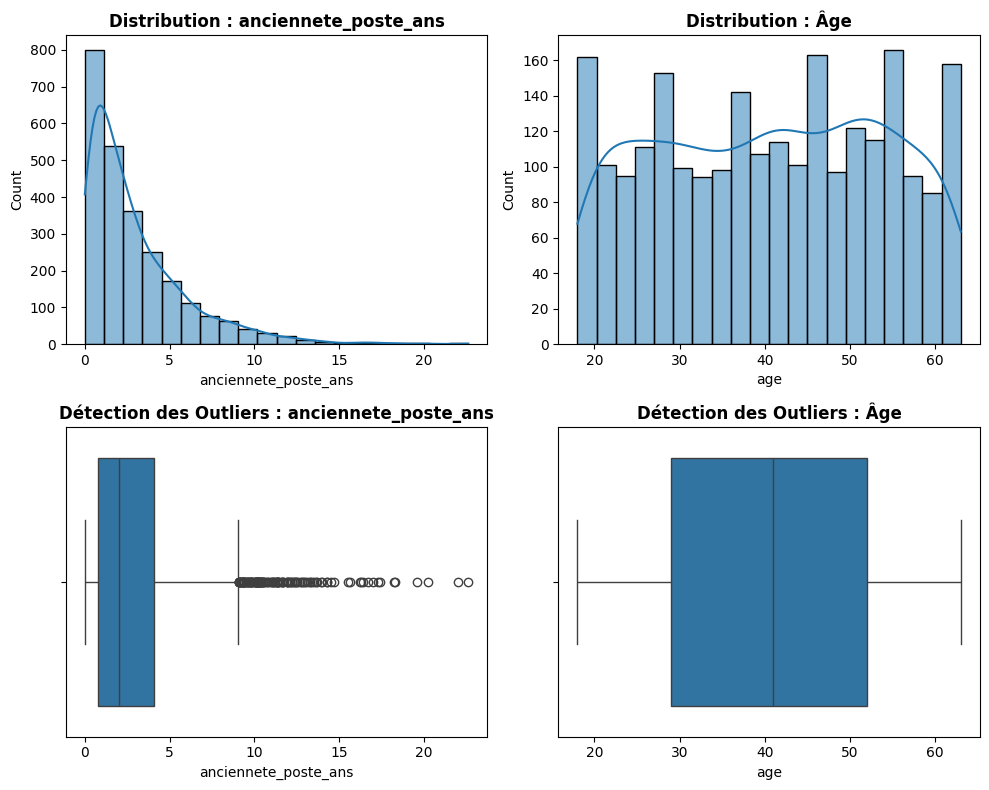

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].set_title("Distribution : anciennete_poste_ans", fontsize=12, fontweight='bold')
sns.histplot(data=df, x="anciennete_poste_ans", bins=20, kde=True, ax=axes[0, 0])

axes[0, 1].set_title("Distribution : Âge", fontsize=12, fontweight='bold')
sns.histplot(data=df, x="age", bins=20, kde=True, ax=axes[0, 1])

axes[1, 0].set_title("Détection des Outliers : anciennete_poste_ans", fontsize=12, fontweight='bold')
sns.boxplot(data=df, x="anciennete_poste_ans", ax=axes[1, 0])

axes[1, 1].set_title("Détection des Outliers : Âge", fontsize=12, fontweight='bold')
sns.boxplot(data=df, x="age", ax=axes[1, 1])

plt.tight_layout()

print("Âge :")
display(df["age"].describe())
print("\nAncienneté :")
display(df["anciennete_poste_ans"].describe())

#### 3.3.2 Analyse des variables catégorielles

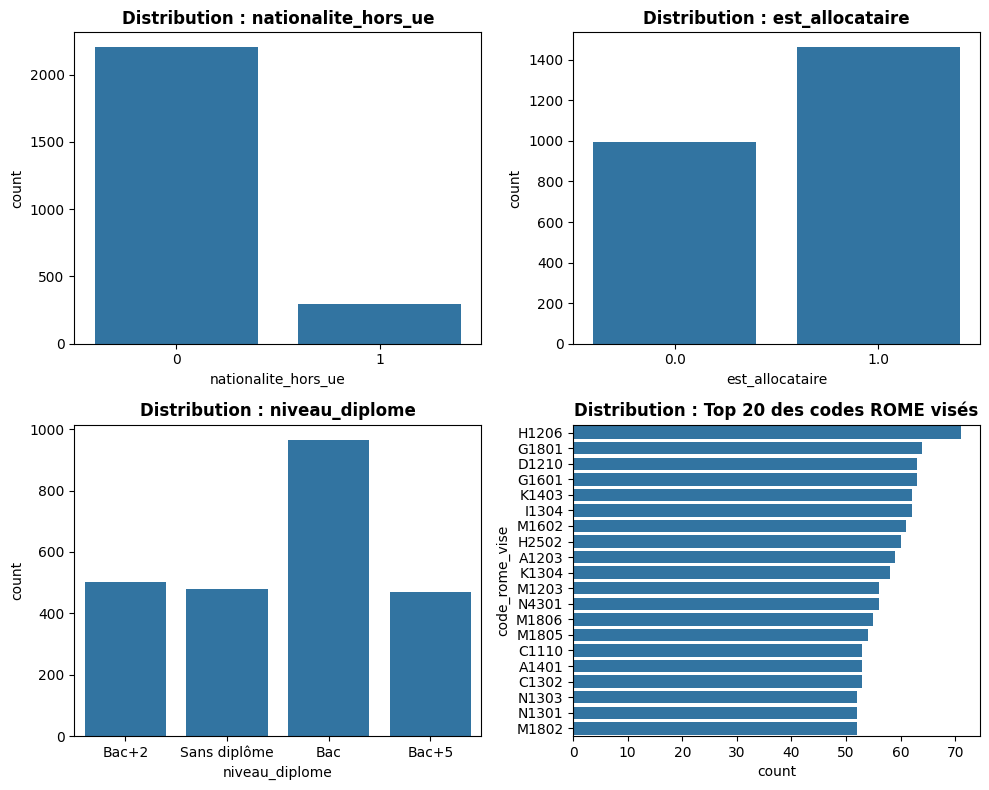

Répartition nationalite_hors_ue :
nationalite_hors_ue
0    0.882
1    0.118
Name: proportion, dtype: float64


In [12]:
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

axes[0, 0].set_title("Distribution : nationalite_hors_ue", fontsize=12, fontweight="bold")
sns.countplot(data=df, x="nationalite_hors_ue", ax=axes[0, 0])

axes[0, 1].set_title("Distribution : est_allocataire", fontsize=12, fontweight="bold")
sns.countplot(data=df, x="est_allocataire", ax=axes[0, 1])

axes[1, 0].set_title("Distribution : niveau_diplome", fontsize=12, fontweight="bold")
sns.countplot(data=df, x="niveau_diplome", ax=axes[1, 0])

top10_rome = df["code_rome_vise"].value_counts().head(20).index
axes[1, 1].set_title("Distribution : Top 20 des codes ROME visés", fontsize=12, fontweight="bold")
sns.countplot(data=df, y="code_rome_vise", order=top10_rome, ax=axes[1, 1])

plt.tight_layout()
plt.show()

print("Répartition nationalite_hors_ue :")
print(df["nationalite_hors_ue"].value_counts(normalize=True).round(3))

#### 3.3.3 Analyse de la variable textuelle

In [13]:
# 3.3 bis Autres types de données — si ton cas n'est pas que du tabulaire
# Une colonne de texte libre, une image, une série temporelle s'explorent AUSSI :
# ce sont des variables, pas des blocs opaques. A adapter, ou a supprimer si ton
# cas est purement tabulaire.
# - combien de valeurs manquantes ou vides ? des doublons ?
# - quelle dispersion (longueur, taille, plage temporelle) ?
# - regarde un echantillon a l'oeil nu : print(df[col].sample(10, random_state=RANDOM_STATE))
# Note en 3.7 ce que tu comptes en faire, et a quel cout.


In [14]:
# Échantillon à l'œil nu
print("\nÉchantillon de 10 synthèses d'entretien :")
for texte in df["synthese_entretien"].dropna().sample(10, random_state=RANDOM_STATE):
    print("-", texte)


Échantillon de 10 synthèses d'entretien :
- Cumul de difficultés. Pas de moyen de transport et garde d'enfants complexe.
- Candidat très dynamique, mobilité nationale validée. Projet clair.
- Excellente présentation, compétences techniques à jour. Reprise rapide visée.
- Compétences à réactualiser sur les outils numériques. Motivation correcte.
- Projet de reconversion à affiner. Besoin d'une formation complémentaire.
- Perte de confiance importante. Risque d'exclusion, barrière de la langue.
- Compétences à réactualiser sur les outils numériques. Motivation correcte.
- Projet de reconversion à affiner. Besoin d'une formation complémentaire.
- Problème ponctuel de mobilité géographique. Zone mal desservie.
- Compétences à réactualiser sur les outils numériques. Motivation correcte.


In [15]:
# Valeurs manquantes / vides
n_na = df["synthese_entretien"].isna().sum()
n_vide = (df["synthese_entretien"].fillna("").str.strip() == "").sum()
print(f"Valeurs manquantes : {n_na} ({n_na/len(df)*100:.1f} %)")
print(f"Chaînes vides ou blanches : {n_vide}")

Valeurs manquantes : 81 (3.2 %)
Chaînes vides ou blanches : 81


Textes uniques : 9
Doublons de texte hors NA : 2410



synthese_entretien
Compétences à réactualiser sur les outils numériques. Motivation correcte.       338
Problème ponctuel de mobilité géographique. Zone mal desservie.                  334
Profil autonome, recherche active, aucun frein périphérique identifié.           300
Projet de reconversion à affiner. Besoin d'une formation complémentaire.         275
Excellente présentation, compétences techniques à jour. Reprise rapide visée.    272
Candidat très dynamique, mobilité nationale validée. Projet clair.               259
Cumul de difficultés. Pas de moyen de transport et garde d'enfants complexe.     227
Perte de confiance importante. Risque d'exclusion, barrière de la langue.        212
Freins périphériques majeurs. Situation d'illettrisme numérique constatée.       202
NaN                                                                               81
Name: count, dtype: int64

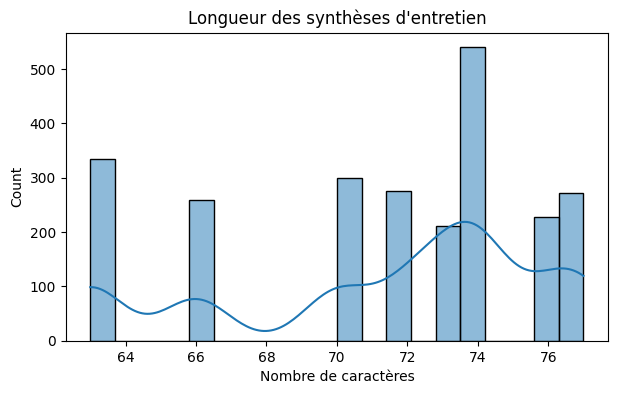

count    2419.000000
mean       71.338570
std         4.516476
min        63.000000
25%        70.000000
50%        73.000000
75%        74.000000
max        77.000000
Name: texte_len, dtype: float64


In [16]:
# Doublons
n_unique_text = df["synthese_entretien"].nunique(dropna=True)
n_dup_text = df["synthese_entretien"].dropna().duplicated().sum()

print(f"Textes uniques : {n_unique_text}")
print(f"Doublons de texte hors NA : {n_dup_text}\n")
display(df["synthese_entretien"].value_counts(dropna=False).head(15))

plt.figure(figsize=(7,4))

df["texte_len"] = df["synthese_entretien"].str.len()
sns.histplot(df['texte_len'].dropna(), bins=20, kde=True)
# Longueur du texte libre (proxy de richesse informative) 
plt.title("Longueur des synthèses d'entretien")
plt.xlabel("Nombre de caractères")
plt.show()
print(df['texte_len'].describe())

#### 3.3.4 Exploration de regroupements potentiels

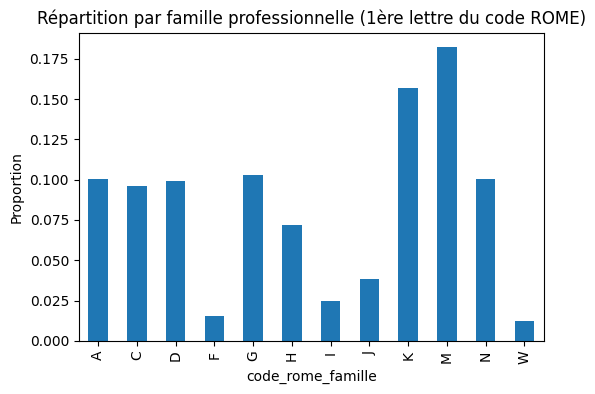

ROME uniques      : 50
Familles ROME     : 12


In [17]:
# Répartition par famille professionnelle (1ère lettre du code ROME)
df["code_rome_famille"] = df["code_rome_vise"].str[0]

# Visualisation complémentaire : répartition par famille
plt.figure(figsize=(6, 4))
df["code_rome_famille"].value_counts(normalize=True).sort_index().plot(kind="bar")
plt.title("Répartition par famille professionnelle (1ère lettre du code ROME)")
plt.ylabel("Proportion")
plt.show()
print("ROME uniques      :", df["code_rome_vise"].nunique())
print("Familles ROME     :", df["code_rome_famille"].nunique())

In [18]:
df["groupe_age"] = pd.cut(
    df["age"], bins=[0, 30, 50, 100],
    labels=["<30", "30-50", "50+"]
)

distribution = df["groupe_age"].value_counts().reindex(["<30", "30-50", "50+"])
distribution_pct = df["groupe_age"].value_counts(normalize=True).reindex(["<30", "30-50", "50+"]) * 100

tableau = pd.DataFrame({
    "effectif": distribution,
    "pourcentage": distribution_pct.round(1)
})
print(tableau)

            effectif  pourcentage
groupe_age                       
<30              671         28.2
30-50           1032         43.4
50+              675         28.4


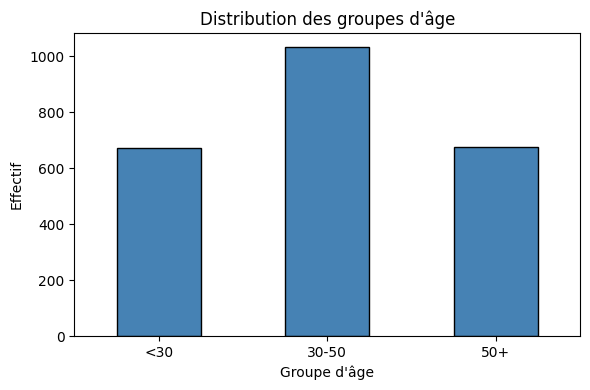

In [19]:
ordre = ["<30", "30-50", "50+"]
distribution = df["groupe_age"].value_counts().reindex(ordre)

plt.figure(figsize=(6, 4))
distribution.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Distribution des groupes d'âge")
plt.xlabel("Groupe d'âge")
plt.ylabel("Effectif")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Nombre de départements     : 96


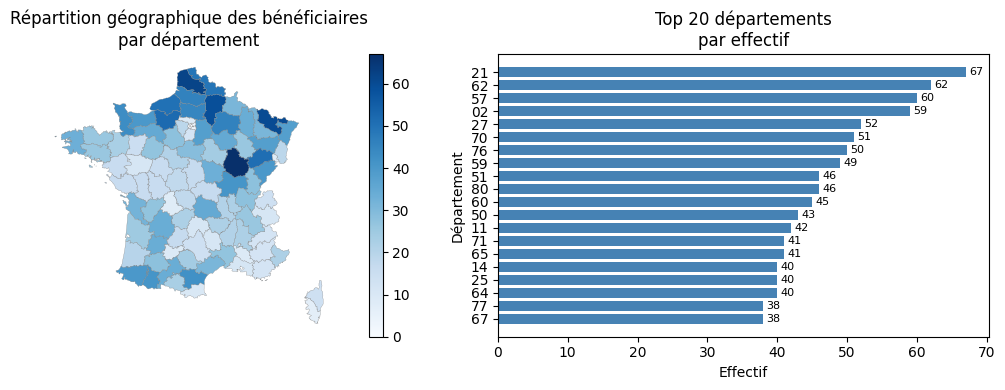

In [20]:
# Carte de répartition géographique : département + Top 20

# Comme code_insee_commune contient généralement les 5 chiffres INSEE
df["code_insee_commune"] = df["code_insee_commune"].astype(str).str.zfill(5)
df["departement"] = df["code_insee_commune"].astype(str).str[:2]
print("Nombre de départements     :", df["departement"].nunique())

# Correction DROM (codes à 3 chiffres tronqués par le str[:2])
is_drom = df["code_insee_commune"].astype(str).str.startswith("97")
df.loc[is_drom, "departement"] = df["code_insee_commune"].astype(str).str[:3]

# --- Effectifs par département ---
dep_counts = df["departement"].value_counts().reset_index()
dep_counts.columns = ["code", "effectif"]

# --- Chargement du fond de carte départemental ---
# !pip install geopandas
france = gpd.read_file("../data/departements.geojson")

# --- Carte : répartition par département ---
carte_dep = france.merge(dep_counts, left_on="code", right_on="code", how="left")
carte_dep["effectif"] = carte_dep["effectif"].fillna(0)

# --- Top 20 départements ---
top20 = dep_counts.sort_values("effectif", ascending=False).head(20)

# --- Affichage : carte + top 20 ---
fig, axes = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"width_ratios": [1.3, 1]})

carte_dep.plot(column="effectif", cmap="Blues", legend=True, ax=axes[0],
               edgecolor="grey", linewidth=0.2)
axes[0].set_title("Répartition géographique des bénéficiaires\npar département")
axes[0].axis("off")

axes[1].barh(top20["code"].astype(str), top20["effectif"], color="steelblue")
axes[1].invert_yaxis()  # le département le plus représenté en haut
axes[1].set_title("Top 20 départements\npar effectif")
axes[1].set_xlabel("Effectif")
axes[1].set_ylabel("Département")

for i, v in enumerate(top20["effectif"]):
    axes[1].text(v + 0.5, i, str(int(v)), va="center", fontsize=8)

plt.tight_layout()
plt.show()

📝 **Synthèse(§3.3)**

**Variables numériques :**
- `age`: Distribution quasi-uniforme entre 18 et 63 ans (moyenne 40,6, médiane 41), aucun outlier détecté (boxplot sans point aberrant). 
- `anciennete_poste_ans`: Distribution très asymétrique à droite (moyenne 2,97, médiane 2, max 22,6). Le boxplot révèle un nombre important d'outliers au-delà de ~9 ans.

**Variables catégorielles :**
- `nationalite_hors_ue` : fort déséquilibre, 88,2% / 11,8%. À anticiper pour tout test de fairness (le sous-groupe minoritaire sera statistiquement fragile, risque de sur- ou sous-performance du modèle sur cette population).
- `est_allocataire` : répartition plus équilibrée (~40% / 60%).
- `niveau_diplome` : "Bac" nettement dominant (~38%), les trois autres modalités (Sans diplôme, Bac+2, Bac+5) réparties de façon comparable (~19% chacune).
- `code_rome_vise` : 50 modalités / 12 familles professionnelles.
Le code H1206 domine nettement le top 20. La répartition par famille (1ère lettre du code ROME) montre une sur-représentation d'une ou deux familles (~15-17,5% contre ~10% pour les autres).
- `departement` : 96 départements représentés sur les 2500 usagers. Le département le plus représenté totalise ~67 usagers, sans concentration extrême (le top 20 s'échelonne de 38 à 67) — la répartition est diffuse, ce qui est plutôt rassurant pour le risque de ré-identification par la seule variable département (contrairement au niveau commune, beaucoup plus problématique).

**Variable textuelle :**
- `synthese_entretien` :
81 valeurs manquantes/vides (3,2%).
Sur les 2419 valeurs restantes, on ne compte que 9 textes uniques — malgré des doublons quasi systématiques (2410 doublons détectés).
La longueur est resserrée entre 63 et 77 caractères (cohérent avec un champ templaté, pas du texte libre spontané).
cette variable n'est pas du texte libre au sens propre, mais un champ à choix quasi-fermé (9 phrases-types récurrentes, ex. "Barrière de la langue", "Situation d'illettrisme numérique constatée", "Problème ponctuel de mobilité géographique").

**`groupe_age` : <30 ans = 28,2%, 30-50 ans = 43,4%, 50+ = 28,4% — répartition équilibrée entre les trois tranches.**

### 3.4 Variable cible : équilibre des classes / distribution

In [21]:
# 3.4 Variable cible : équilibre des classes / distribution
# df["target"].value_counts(normalize=True)

Distribution de la variable cible :


classe_retour_emploi
1    44.48%
0    37.44%
2    18.08%
Name: proportion, dtype: object

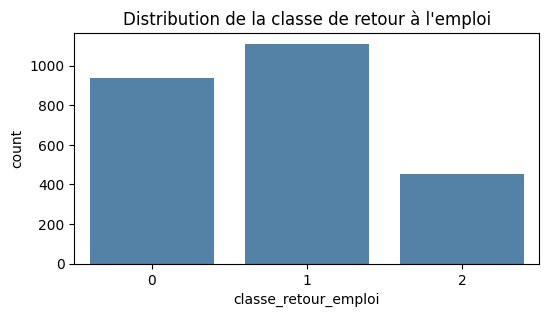

In [22]:
# Distribution de la cible
print("Distribution de la variable cible :")
display((df["classe_retour_emploi"].value_counts(normalize=True) * 100).round(2).astype(str) + '%')

plt.figure(figsize=(6, 3))
sns.countplot(data=df, x="classe_retour_emploi",color="steelblue")
plt.title("Distribution de la classe de retour à l'emploi")
plt.show()


📝 **Synthèse (§3.4)**

Répartition observée
Classe 1 (retour 6-12 mois) : 44,48%
Classe 0 (retour <6 mois) : 37,44%
Classe 2 (retour >12 mois) : 18,08%

La cible est modérément déséquilibrée. La classe 2 (retour >12 mois) est la minoritaire, avec un peu moins de la moitié de l'effectif de la classe majoritaire (18,08% vs 44,48%).

**Implications pour la modélisation

Métrique d'évaluation : l'accuracy seule serait trompeuse (un modèle qui prédit toujours la classe 1 obtiendrait déjà ~44% de bonne classification). Privilégier F1-score macro ou pondéré, matrice de confusion par classe, et un focus particulier sur le rappel de la classe 2 — c'est souvent la 
classe la plus critique d'un point de vue métier (La classe 2 correspond aux personnes dont le délai estimé/observé de retour à l'emploi est supérieur à 12 mois et constitue donc une classe particulièrement importante à surveiller dans le cadre de l'orientation).

Stratégie de rééquilibrage à envisager : selon l'algorithme choisi, un class_weight="balanced" (scikit-learn), un sur-échantillonnage ciblé (SMOTE) sur la classe 2, ou un seuillage ajusté post-prédiction peuvent être pertinents. À tester plutôt qu'à appliquer par défaut, car un rééquilibrage agressif sur seulement 2500 lignes peut introduire du bruit.

Lien avec l'enjeu de fairness déjà identifié : le déséquilibre de la cible se combine avec le déséquilibre déjà repéré sur nationalite_hors_ue (88,2%/11,8%). Si le sous-groupe minoritaire de nationalité est aussi sur-représenté dans la classe 2 (à vérifier par un croisement), le risque de mauvaise performance différenciée entre sous-groupes est d'autant plus élevé — point à intégrer dans l'audit de biais prévu.

Action recommandée avant modélisation : croiser classe_retour_emploi avec nationalite_hors_ue, groupe_age et departement pour vérifier si le déséquilibre de classe est uniformément réparti ou concentré dans certains sous-groupes — ce croisement conditionnera le choix de la stratégie de rééquilibrage et les métriques de suivi par sous-population.**

### 3.5 Corrélations & relations entre variables

In [23]:
# 3.5 Corrélations & relations entre variables
# Matrice de corrélation, pairplot, croisements clés vs cible
# À ajouter en 3.5

#### 3.5.1 Matrice de corrélation (variables numériques)

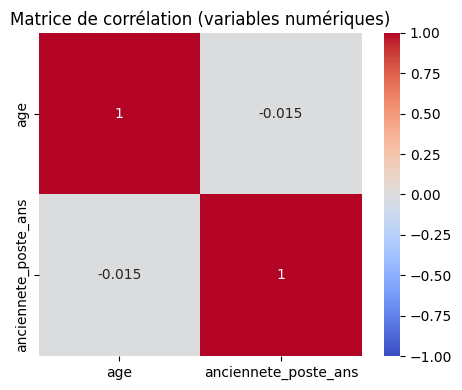

                           age  anciennete_poste_ans
age                   1.000000             -0.015234
anciennete_poste_ans -0.015234              1.000000


In [24]:
num_vars = ['age', 'anciennete_poste_ans']

corr = df[num_vars].corr()
plt.figure(figsize=(5, 4))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, square=True)
plt.title("Matrice de corrélation (variables numériques)")
plt.tight_layout()
plt.show()
print(corr)

#### 3.5.2 Pairplot numériques par la cible

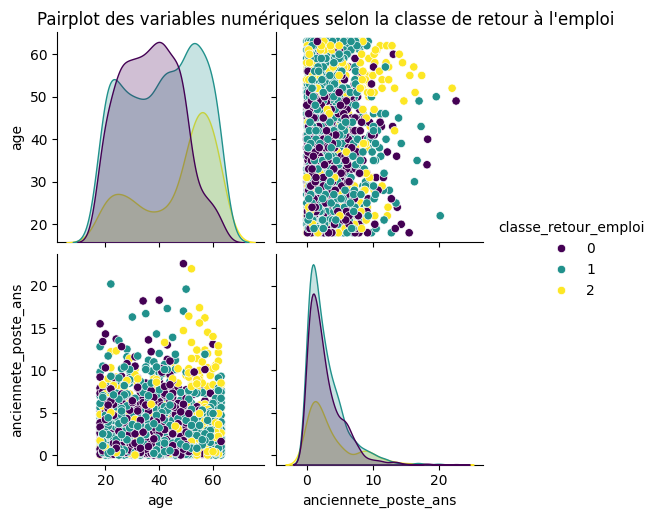

In [25]:
sns.pairplot(df[num_vars + ['classe_retour_emploi']],
             hue='classe_retour_emploi', palette='viridis', diag_kind='kde')
plt.suptitle("Pairplot des variables numériques selon la classe de retour à l'emploi", y=1.02)
plt.show()


#### 3.5.3 Croisements : numériques vs cible (moyenne par classe)


Moyenne des variables numériques par classe cible :
                            age  anciennete_poste_ans
classe_retour_emploi                                 
0                     36.791855              2.782799
1                     41.296890              2.875899
2                     46.482679              3.598009


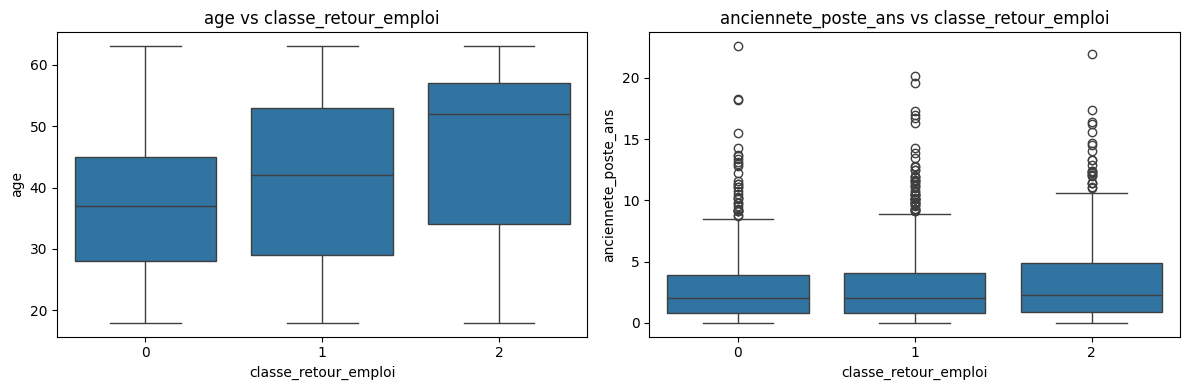

In [26]:
print("\nMoyenne des variables numériques par classe cible :")
print(df.groupby('classe_retour_emploi')[num_vars].mean())

fig, axes = plt.subplots(1, len(num_vars), figsize=(12, 4))
for i, col in enumerate(num_vars):
    sns.boxplot(x='classe_retour_emploi', y=col, data=df, ax=axes[i])
    axes[i].set_title(f'{col} vs classe_retour_emploi')
plt.tight_layout()
plt.show()

#### 3.5.3 Croisements : catégorielles vs cible

In [27]:
# BLOC 1 : Tableaux croisés + test du Chi² (calcul, pas d'affichage graphique)

pd.set_option('display.max_rows', None)  # évite toute troncature de l'affichage

cat_vars = ['niveau_diplome', 'nationalite_hors_ue', 'est_allocataire',
            'departement', 'code_rome_vise', 'synthese_entretien']

resultats_chi2 = {}  # stocke tout pour réutilisation (visualisation, rapport)

for col in cat_vars:
    ct_full = pd.crosstab(df[col], df['classe_retour_emploi'], normalize='index')
    ct_raw = pd.crosstab(df[col], df['classe_retour_emploi'])

    chi2, p, dof, expected = chi2_contingency(ct_raw)
    resultats_chi2[col] = {"chi2": chi2, "p": p, "dof": dof, "ct": ct_full}

    print(f"\n--- {col} vs classe_retour_emploi (proportions par ligne) ---")
    print(ct_full.round(3).to_string())
    print(f"Chi² = {chi2:.2f}, p-value = {p:.4f}  (n modalités = {ct_full.shape[0]})")

pd.reset_option('display.max_rows')


--- niveau_diplome vs classe_retour_emploi (proportions par ligne) ---
classe_retour_emploi      0      1      2
niveau_diplome                           
Bac                   0.377  0.481  0.142
Bac+2                 0.377  0.495  0.128
Bac+5                 0.635  0.293  0.072
Sans diplôme          0.119  0.467  0.414
Chi² = 390.63, p-value = 0.0000  (n modalités = 4)

--- nationalite_hors_ue vs classe_retour_emploi (proportions par ligne) ---
classe_retour_emploi      0      1      2
nationalite_hors_ue                      
0                     0.406  0.440  0.154
1                     0.139  0.481  0.380
Chi² = 123.67, p-value = 0.0000  (n modalités = 2)

--- est_allocataire vs classe_retour_emploi (proportions par ligne) ---
classe_retour_emploi      0      1      2
est_allocataire                          
0.0                   0.379  0.435  0.186
1.0                   0.371  0.452  0.177
Chi² = 0.74, p-value = 0.6895  (n modalités = 2)

--- departement vs classe_retour_emplo

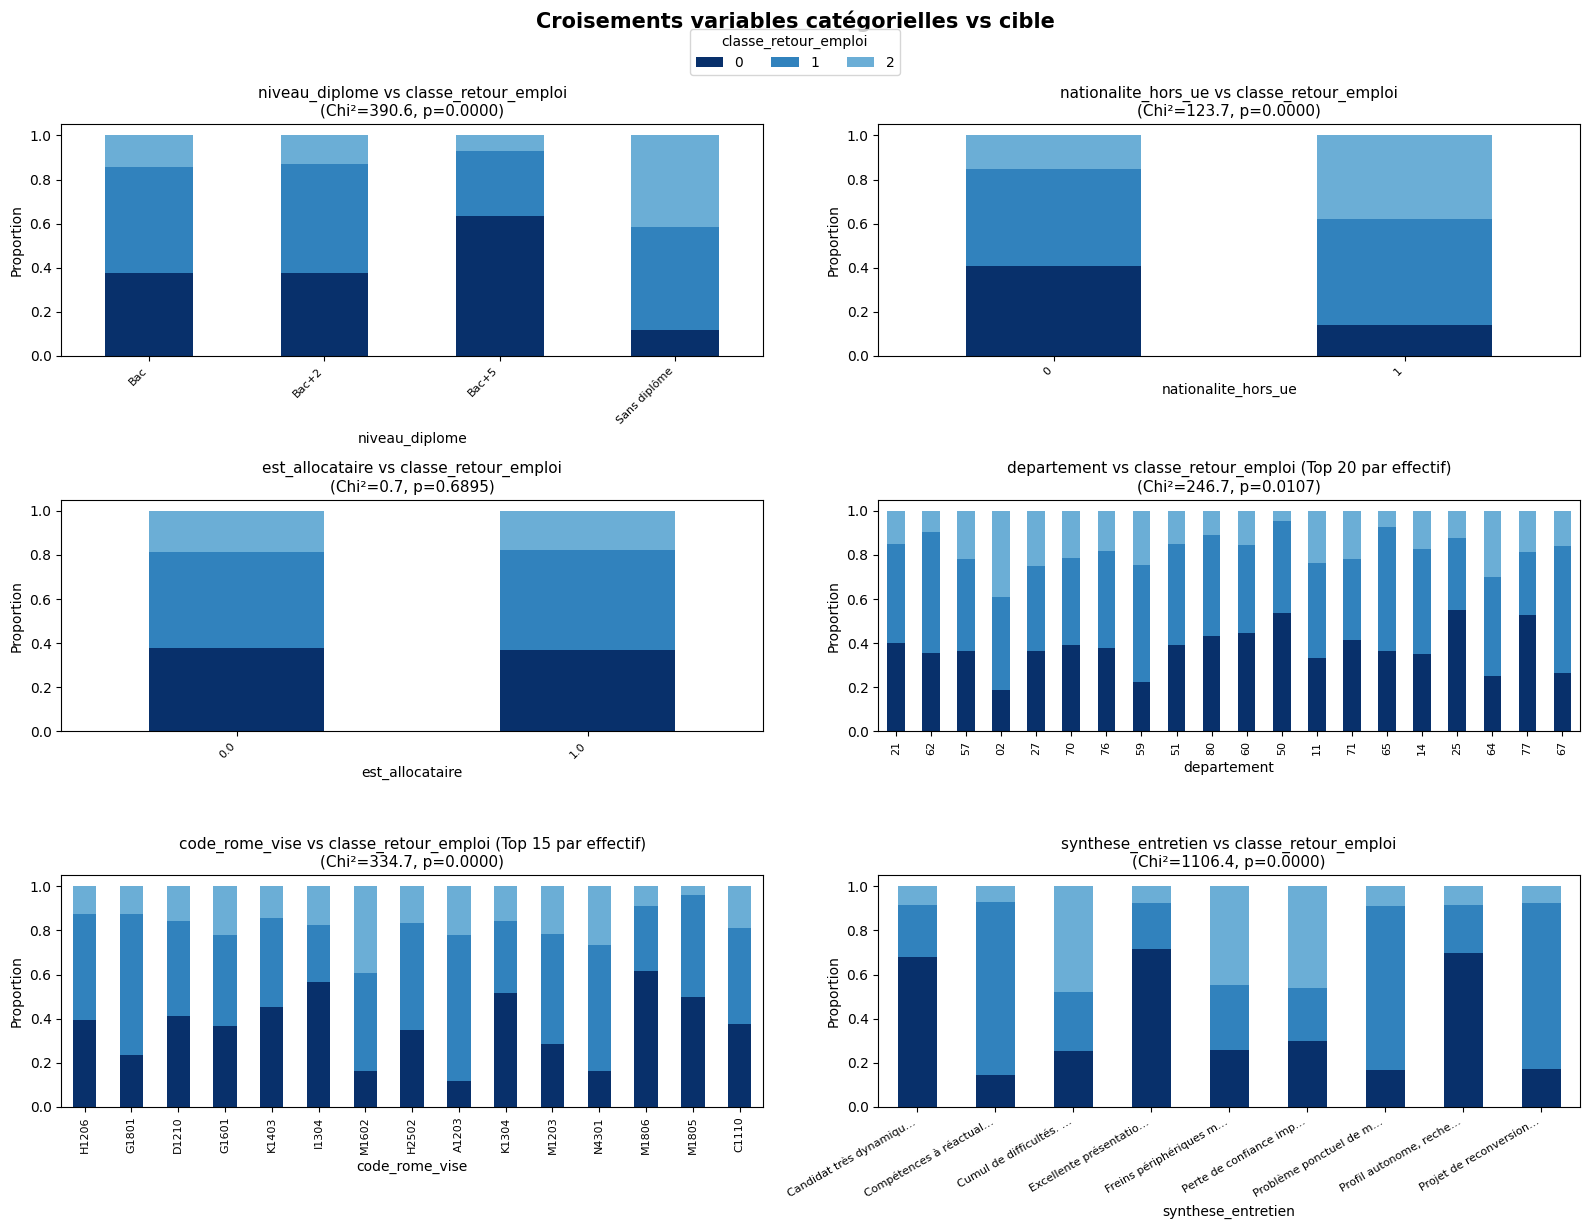

In [28]:
# ============================================================
# BLOC 2 : Visualisation (réutilise resultats_chi2 calculé au bloc 1)
# ============================================================

# Palette bleue personnalisée (du plus foncé au plus clair, clair remonté en intensité)
palette_bleue = ['#08306b', '#3182bd', '#6baed6']

n_vars = len(cat_vars)
n_cols = 2
n_rows = -(-n_vars // n_cols)  # arrondi supérieur

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(cat_vars):
    ct_full = resultats_chi2[col]["ct"]
    chi2 = resultats_chi2[col]["chi2"]
    p = resultats_chi2[col]["p"]

    # --- Cas particulier : departement (96 modalités) → Top 20 par effectif ---
    if col == "departement":
        top_n = df[col].value_counts().head(20).index
        ct = ct_full.loc[top_n]
        titre_extra = " (Top 20 par effectif)"
        rotation, ha = 90, "center"

    # --- Cas particulier : code_rome_vise (50 modalités) → Top 15 par effectif ---
    elif col == "code_rome_vise":
        top_n = df[col].value_counts().head(15).index
        ct = ct_full.loc[top_n]
        titre_extra = " (Top 15 par effectif)"
        rotation, ha = 90, "center"

    # --- Cas particulier : synthese_entretien (9 phrases longues) → labels raccourcis ---
    elif col == "synthese_entretien":
        ct = ct_full.copy()
        ct.index = [label[:22] + "…" if len(label) > 22 else label for label in ct.index]
        titre_extra = ""
        rotation, ha = 30, "right"

    else:
        ct = ct_full
        titre_extra = ""
        rotation, ha = 45, "right"

    ct.plot(kind='bar', stacked=True, color=palette_bleue, ax=axes[i], legend=False)
    axes[i].set_title(f'{col} vs classe_retour_emploi{titre_extra}\n(Chi²={chi2:.1f}, p={p:.4f})',
                       fontsize=11)
    axes[i].set_ylabel('Proportion')
    axes[i].set_xlabel(col)
    axes[i].tick_params(axis='x', rotation=rotation)
    for label in axes[i].get_xticklabels():
        label.set_ha(ha)
        label.set_fontsize(8)

# Masque les sous-graphiques vides si besoin
for j in range(n_vars, len(axes)):
    axes[j].axis("off")

# Légende unique partagée
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, title='classe_retour_emploi',
           loc='upper center', bbox_to_anchor=(0.5, 1.01), ncol=3)

plt.suptitle("Croisements variables catégorielles vs cible", fontsize=15, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()

📝 **Synthèse (§3.5)**

**Numériques** : 
- `age` porte un vrai signal monotone (36,8 → 41,3 → 46,5 ans selon la classe) et sépare visiblement les distributions dans le pairplot ;
- `anciennete_poste_ans` n'apporte quasiment rien (2,78 → 2,88 → 3,60 ans, aucune séparation visuelle), sans colinéarité entre les deux (r=-0,015).

**Catégorielles** : L'analyse du Chi² met en évidence des associations statistiques entre certaines variables catégorielles et la classe cible. Les valeurs de χ² les plus élevées sont observées pour `synthese_entretien`, `niveau_diplome` et  `code_rome_vise`.

### 3.6 Analyse des biais & variables sensibles

*[Quelles variables peuvent porter un biais (genre, âge, origine, profession des parents…) ? La cible est-elle inégalement répartie selon ces variables ? Disparate impact ?]*

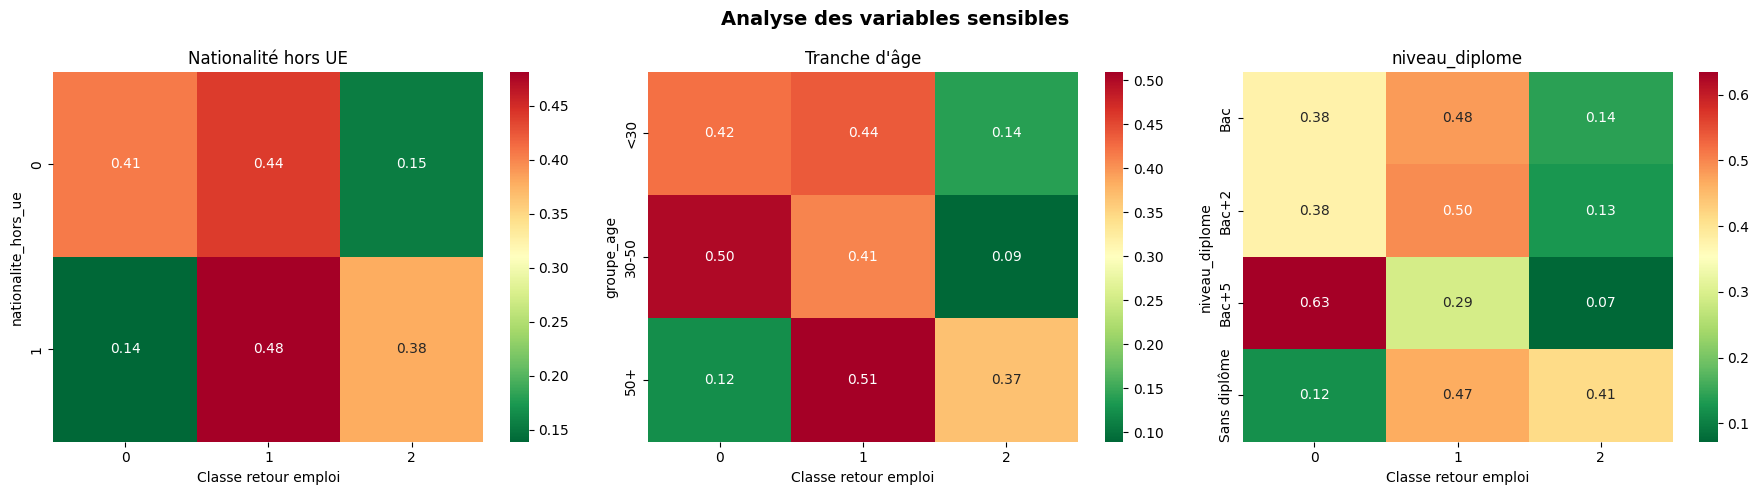

In [29]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Nationalité hors UE

ct_nat = pd.crosstab(
    df["nationalite_hors_ue"],
    df["classe_retour_emploi"],
    normalize="index"
)

sns.heatmap(
    ct_nat,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn_r",
    ax=axes[0]
)

axes[0].set_title("Nationalité hors UE")
axes[0].set_xlabel("Classe retour emploi")
axes[0].set_ylabel("nationalite_hors_ue")

# 2. Groupe d'âge


ct_age = pd.crosstab(
    df["groupe_age"],
    df["classe_retour_emploi"],
    normalize="index"
)

sns.heatmap(
    ct_age,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn_r",
    ax=axes[1]
)

axes[1].set_title("Tranche d'âge")
axes[1].set_xlabel("Classe retour emploi")
axes[1].set_ylabel("groupe_age")


# 3. niveau_diplome

ct_alloc = pd.crosstab(
    df["niveau_diplome"],
    df["classe_retour_emploi"],
    normalize="index"
)

sns.heatmap(
    ct_alloc,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn_r",
    ax=axes[2]
)

axes[2].set_title("niveau_diplome")
axes[2].set_xlabel("Classe retour emploi")
axes[2].set_ylabel("niveau_diplome")

plt.suptitle("Analyse des variables sensibles", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.show()

In [30]:
# Vérification empirique du biais lexical suspecté sur synthese_entretien (cf. §2.4)
texte = df["synthese_entretien"].fillna("").str.lower()

# Recherche de mentions explicites de critères sensibles
patterns = {
    "age_mention": r"\b(?:\d+\s*ans|jeune|âgé|senior|ans\b)",
    "origine_mention": r"\b(?:étranger|immigr|nationalité|origine)",
    "genre_mention": r"\b(?:madame|monsieur)",
}
for label, pattern in patterns.items():
    n = texte.str.contains(pattern, regex=True, na=False).sum()
    print(f"{label} : {n} occurrences sur {texte.notna().sum()} textes ({n/len(df)*100:.1f} %)")

# Le texte permet-il de prédire une variable sensible ? (signal de biais lexical implicite)
tfidf = TfidfVectorizer(max_features=200, min_df=5)
X_text = tfidf.fit_transform(texte)

for sensible_col in ["nationalite_hors_ue", "groupe_age"]:
    y = df[sensible_col]
    mask = y.notna()
    if y[mask].nunique() < 2:
        continue
    clf = LogisticRegression(max_iter=1000)  # multi_class retiré (déprécié, comportement par défaut = multinomial)
    scoring = "roc_auc_ovr" if y[mask].nunique() > 2 else "roc_auc"
    scores = cross_val_score(clf, X_text[mask.values], y[mask], cv=5, scoring=scoring)
    print(f"\nAUC texte → {sensible_col} : {scores.mean():.3f} (proche de 0.5 = pas de biais lexical détecté)")

age_mention : 0 occurrences sur 2500 textes (0.0 %)
origine_mention : 0 occurrences sur 2500 textes (0.0 %)
genre_mention : 0 occurrences sur 2500 textes (0.0 %)

AUC texte → nationalite_hors_ue : 0.542 (proche de 0.5 = pas de biais lexical détecté)

AUC texte → groupe_age : 0.543 (proche de 0.5 = pas de biais lexical détecté)


In [31]:
# Fonction de calcul du Disparate Impact (règle des 4/5)

def disparate_impact(df, sensitive_col, target_col, positive_value,
                      min_group_size=None):
    
    grp = df.groupby(sensitive_col, observed=True)[target_col]
    sizes = grp.size()
    selection_rate = grp.apply(lambda x: (x == positive_value).mean())

    n_exclus = 0
    if min_group_size is not None:
        keep = sizes[sizes >= min_group_size].index
        n_exclus = len(selection_rate) - len(keep)
        selection_rate = selection_rate.loc[keep]

    sr_min, sr_max = selection_rate.min(), selection_rate.max()
    di = sr_min / sr_max  # toujours ≤ 1 par construction (min/max)

    verdict = "⚠️ Signal" if di < 0.8 else "✅ OK"

    return {
        "Variable": sensitive_col,
        "N groupes": len(selection_rate),
        "N groupes exclus (< seuil)": n_exclus,
        "Selection Rate min": round(sr_min, 3),
        "Selection Rate max": round(sr_max, 3),
        "DI": round(di, 3),
        "Verdict": verdict
    }

In [32]:
# Critères de discrimination

sensitive_vars = ["nationalite_hors_ue", "groupe_age", "est_allocataire", "niveau_diplome"]

results = []
for var in sensitive_vars:
    results.append(
        disparate_impact(
            df=df, sensitive_col=var, target_col="classe_retour_emploi",
            positive_value=0
        )
    )

di_table = pd.DataFrame(results).sort_values(by="DI").reset_index(drop=True)
di_table

,Variable,N groupes,N groupes exclus (< seuil),Selection Rate min,Selection Rate max,DI,Verdict
0,niveau_diplome,4,0,0.119,0.635,0.188,⚠️ Signal
1,groupe_age,3,0,0.123,0.501,0.245,⚠️ Signal
2,nationalite_hors_ue,2,0,0.139,0.406,0.342,⚠️ Signal
3,est_allocataire,2,0,0.371,0.379,0.980,✅ OK


### 3.7 📝 Synthèse EDA

*[Top 5 enseignements de l'EDA. Hypothèses de travail pour la modélisation. Risques de biais identifiés. **Révision éventuelle des cibles 1.4** à la lumière de la donnée.]*

**1. La cible présente un déséquilibre modéré**

La classe 2 (>12 mois) représente environ 18 % des observations, contre 37 % pour la classe 0 et 44 % pour la classe 1. Une bonne performance globale pourrait masquer une mauvaise détection de cette classe minoritaire. Les métriques privilégiées seront donc le F1-macro, le rappel de la classe 2 et l'analyse détaillée de la matrice de confusion.

**2. L'âge apparaît comme la variable numérique la plus informative**

L'âge moyen augmente de façon monotone entre les trois classes (36,8 → 41,3 → 46,5 ans), ce qui suggère un fort pouvoir discriminant. À l'inverse, l'ancienneté du dernier poste semble apporter un signal plus limité. L'apport réel de ces variables sera confirmé par la modélisation et non uniquement par l'EDA.

**3. Plusieurs variables catégorielles présentent une association forte avec la cible**

Les variables synthese_entretien, niveau_diplome, code_rome_vise, departement et nationalite_hors_ue présentent des associations statistiquement significatives avec la cible. Elles constituent des candidates pertinentes pour la modélisation, sous réserve d'une analyse complémentaire de leurs implications éthiques et réglementaires.

**4. La variable textuelle constitue une source d'information importante mais atypique**

La variable synthese_entretien présente le niveau d'association le plus élevé avec la cible. Cependant, elle ne contient que neuf formulations distinctes réutilisées sur l'ensemble du jeu de données. Elle sera comparée à des scénarios sans texte afin de mesurer sa contribution réelle et d'écarter un éventuel risque de fuite d'information ou de surapprentissage.

**5. Des risques de biais significatifs sont identifiés**

L'analyse de fairness met en évidence des signaux de disparité pour l'âge (DI = 0,245) et la nationalité (DI = 0,342), tandis que le statut d'allocataire ne présente pas de déséquilibre notable. En outre, le département et le niveau de diplôme peuvent agir comme variables proxy de caractéristiques socio-économiques ou démographiques. Plusieurs scénarios de modélisation seront donc comparés afin d'évaluer le compromis entre performance prédictive et réduction des risques de discrimination.

**Hypothèses de travail pour la modélisation**
- Le scénario complet devrait offrir la meilleure performance prédictive.
- La suppression de nationalite_hors_ue pourrait avoir un impact limité sur les performances tout en réduisant le risque juridique.
- La suppression simultanée des variables sensibles et des principaux proxies (age, nationalite_hors_ue, departement, éventuellement niveau_diplome) permettra d'évaluer le coût réel d'une approche d'IA plus responsable.
- La comparaison entre scénarios tabulaires et textuels permettra de quantifier l'apport spécifique de la variable synthese_entretien.
- Le choix final sera effectué sur la base d'un compromis entre performance, robustesse, explicabilité et équité.

| Type | Critère | Cible initiale (client) | Cible révisée après EDA | Justification de la révision |
|---|---|---|---|---|
| Métier | Taux d'erreur critique de sous-classement (Faux Négatifs Classe 2) | Minimum possible (aiguillage fiable) | Taux d'erreur Classe 2 → Classe 0 < 5% | Classer un usager à risque de longue durée (Classe 2) en retour rapide (Classe 0) est l'erreur la plus grave : elle prive l'usager d'un accompagnement renforcé indispensable, avec un coût humain et financier majeur. Seuils de décision et pondération des classes seront ajustés pour pénaliser spécifiquement cette erreur. |
| Modèle | Recall (rappel) de la Classe 2 | Non spécifié explicitement | Recall Classe 2 ≥ 0.85 | Métrique technique directement liée à la contrainte métier ci-dessus : un recall élevé sur la Classe 2 garantit que la majorité des usagers réellement à risque de longue durée sont détectés comme tels. Le seuil se déduit de la tolérance d'erreur < 5% fixée par le métier, à ajuster après les premiers entraînements. Seuils de décision et pondération des classes seront ajustés pour maximiser ce recall, quitte à sacrifier un peu de précision sur cette classe. |
| Modèle | F1-score macro | Non spécifié explicitement | F1-score macro ≥ 0.75 | L'EDA a révélé un déséquilibre modéré des classes (Classe 2 = 18,1%), rendant l'accuracy seule trompeuse. Le F1-macro est retenu pour garantir une performance équitable sur les trois classes, notamment la classe minoritaire à risque. |
| Modèle | Accuracy globale | Maximale | Accuracy ≥ 0.80 | Baseline de cohérence exigée par le sujet : l'accuracy doit rester élevée pour valider la performance sur les classes majoritaires (0 et 1), mais reste secondaire au recall Classe 2, au F1-macro et à la matrice de confusion. |
| Éthique & Légal | Disparate Impact (règle des 4/5) | Non spécifié (conformité RGPD) | DI ≥ 0.80, mesuré sur les prédictions du modèle en production | L'EDA sur les données brutes révèle un déséquilibre du taux de retour rapide selon l'âge (DI=0.245) et la nationalité (DI=0.342), reflet de facteurs socio-économiques structurels préexistants. Le scénario retenu (Scénario 2, sans variables sensibles) devra être audité pour vérifier que ses prédictions ne reproduisent ni n'amplifient ce déséquilibre — fondement : RGPD (art. 5/6/22, licéité et décision automatisée), art. 225-1 du Code pénal (critères de discrimination), et AI Act (système à haut risque, accès à l'emploi). |
| Opérationnel | Temps de réponse de l'API (inférence) | Latence acceptable en face-à-face | Latence p95 < 200 ms | Le conseiller utilise l'application en direct avec l'usager lors de l'entretien. L'inférence multimodale (tabulaire + texte) via l'API doit être quasi-instantanée pour ne pas ralentir l'échange. |

recall Classe 2 est la métrique de pilotage du critère métier, et le F1-macro/accuracy des métriques de validation globale — cette articulation (métrique métier → métrique technique → métrique de cohérence globale) montre une vraie maîtrise de la traduction besoin métier → spécification ML

---
## 4. Préparation des données

**Compétences** : C3 (préparer les données pour renforcer intégrité et pertinence)

🎯 Construire un **pipeline reproductible** de préprocessing (pas de transformations one-shot dispersées).

💡 `sklearn.compose.ColumnTransformer` + `sklearn.pipeline.Pipeline` = base obligatoire.  
⚠️ Le **train/test split DOIT précéder** tout calcul d'imputation/normalisation, sinon fuite de données.

## 4.1 Train/test split

In [160]:
import sys

PROJECT_DIR = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SRC_DIR = PROJECT_DIR / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

%load_ext autoreload
%autoreload 2

# Import depuis preprocess.py (pas pipeline_tabulaire)
from preprocess import load_dataset, build_preprocessor, get_all_features, SENSITIVE_FEATURES, PROXY_FEATURES

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [161]:
# 4.1 Train/test split (stratifié si classification déséquilibrée)
# from sklearn.model_selection import train_test_split
# X = df.drop(columns=["target"])
# y = df["target"]
# X_train, X_test, y_train, y_test = train_test_split(
#     X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
# )

In [162]:
from train import load_scenario_dataset, split_train_holdout
from config import TEST_SIZE, RANDOM_STATE, SCENARIOS 

# Charger les données + split stratify
resultats_par_scenario = {}
print(f"{'Scénario':25s} | {'X_train':12s} | {'X_holdout':12s} | {'N.col':6s} | Description")
print("-" * 110)

for scenario_name in SCENARIOS.keys():
    X, y = load_scenario_dataset(data_path=RAW_PATH, scenario_name=scenario_name)
    X_train, X_holdout, y_train, y_holdout = split_train_holdout(X=X, y=y)
    resultats_par_scenario[scenario_name] = {
        "X_train": X_train, "X_holdout": X_holdout,
        "y_train": y_train, "y_holdout": y_holdout,
    }
    description = SCENARIOS[scenario_name].get("description", "")
    print(
        f"{scenario_name:25s} | {str(X_train.shape):12s} | {str(X_holdout.shape):12s} "
        f"| {X_train.shape[1]:6d} | {description}"
    )
    print(f"{'':25s} | Colonnes : {list(X_train.columns)}")
    print()

print("TEST_SIZE =", TEST_SIZE)
print("RANDOM_STATE =", RANDOM_STATE)
print("-" * 110)

Scénario                  | X_train      | X_holdout    | N.col  | Description
--------------------------------------------------------------------------------------------------------------
multimodal_complet        | (2000, 8)    | (500, 8)     |      8 | Variables tabulaires, texte et variables sensibles.
                          | Colonnes : ['age', 'anciennete_poste_ans', 'niveau_diplome', 'code_rome_vise', 'departement', 'est_allocataire', 'nationalite_hors_ue', 'synthese_entretien']

multimodal_ethique        | (2000, 6)    | (500, 6)     |      6 | Variables tabulaires et texte sans variables sensibles.
                          | Colonnes : ['anciennete_poste_ans', 'niveau_diplome', 'code_rome_vise', 'departement', 'est_allocataire', 'synthese_entretien']

multimodal_ethique_renforce | (2000, 5)    | (500, 5)     |      5 | S2 bis : variables tabulaires et texte sans variables sensibles ni variables proxy (ethique renforce).
                          | Colonnes : ['anciennete_

## 4.2 Preprocessing

In [163]:
# 4.2 Recette de préprocessing — une FONCTION, pas un objet figé
# Les scénarios de 4.3 changent le PERIMETRE des données utilisées (parfois un
# type de données entier). Les traitements, eux, ne changent pas.
# On écrit donc la recette une fois, on l'instancie par scénario en 5.2.
#
# from sklearn.compose import ColumnTransformer
# from sklearn.pipeline import Pipeline
# from sklearn.impute import SimpleImputer
# from sklearn.preprocessing import StandardScaler, OneHotEncoder
#
# num_pipe = Pipeline([
#     ("imputer", SimpleImputer(strategy="median")),
#     ("scaler", StandardScaler()),
# ])
# cat_pipe = Pipeline([
#     ("imputer", SimpleImputer(strategy="most_frequent")),
#     ("onehot", OneHotEncoder(handle_unknown="ignore")),
# ])
#
# def make_preprocessor(num_features=None, cat_features=None):
#     """Instancie la MEME recette sur le perimetre demande.
#
#     Chaque bloc est OPTIONNEL : c'est ce qui permet a un scenario de 4.3 de
#     retirer un type de donnees entier sans changer les traitements.
#     Meme recette partout = comparabilite.
#     """
#     blocks = []
#     if num_features:
#         blocks.append(("num", num_pipe, num_features))
#     if cat_features:
#         blocks.append(("cat", cat_pipe, cat_features))
#     # TODO si ton cas comporte un autre type de donnees (texte libre, image,
#     #      serie temporelle) : ajoute ici un bloc sur le meme modele, avec le
#     #      transformer adapte et son propre parametre optionnel. A toi de
#     #      trouver la forme d'entree qu'attend ce transformer.
#     assert blocks, "Aucune colonne : verifie le perimetre du scenario"
#     return ColumnTransformer(blocks)
#
# Aucun .fit() ici : le fit se fait dans le Pipeline complet (5.2), sur le train
# de chaque fold de CV. Un fit premature ici = fuite de donnees.


In [164]:
from importlib import reload
import preprocess

reload(preprocess)

from preprocess import (
    get_numeric_features,
    get_ordinal_features,
    get_categorical_features,
)

In [165]:
from preprocess import NUMERIC_FEATURES, ORDINAL_FEATURES, TEXT_FEATURE, BASE_CATEGORICAL_FEATURES
display(get_ordinal_features())
display(get_numeric_features())
display(get_categorical_features())
display(TEXT_FEATURE)

{'niveau_diplome': ['Sans diplôme', 'Bac', 'Bac+2', 'Bac+5']}

['age', 'anciennete_poste_ans']

['code_rome_vise', 'departement', 'est_allocataire', 'nationalite_hors_ue']

'synthese_entretien'

In [166]:
from preprocess import build_preprocessor
preprocessor = build_preprocessor()
display (preprocessor)
print("Pipelines de prétraitement réalisée avec succès")

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'anciennete_poste_ans']),
                                ('ord',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('ordinal',
                                                  OrdinalEncoder(categories=[['Sans '
                                                                              'diplôme',
                                                                              'Bac',
                                                                              'Bac+2',
                                                                              'Bac+5']],
                                                                 encoded_missing_value=-1,
                                                                 handle_un...
                                 Pipeline(steps=[('cleaner', TextCleaner()),
                                                 ('tfidf',
                                                  TfidfVectorizer(max_features=1000,
                                                                  min_df=2,
                                                                  ngram_range=(1,
                                                                               2),
                                                                  stop_words=['a',
                                                                              'afin',
                                                                              'ainsi',
                                                                              'au',
                                                                              'aux',
                                                                              'avec',
                                                                              'ce',
                                                                              'ces',
                                                                              'cet',
                                                                              'cette',
                                                                              'comme',
                                                                              'dans',
                                                                              'de',
                                                                              'des',
                                                                              'du',
                                                                              'elle',
                                                                              'elles',
                                                                              'en',
                                                                              'est',
                                                                              'et',
                                                                              'il',
                                                                              'ils',
                                                                              'je',
                                                                              'la',
                                                                              'le',
                                                                              'les',
                                                                              'leur',
                                                 

Pipelines de prétraitement réalisée avec succès


### 4.3 Scénarios de jeux de données

*[Pour la certif, anticipe : 2 à 4 scénarios = avec/sans variables sensibles, avec/sans certaines variables corrélées à la cible. Liste-les ici, tu les compareras en section 6.]*

| Scénario | Variables conservées | Justification |
|---|---|---|
| S1 | Toutes | Baseline |
| S2 | Sans variables sensibles | Atténuation biais |
| S3 | … | … |


Les scénarios ci-dessous permettent d’évaluer séparément :

- la performance maximale du modèle ;
- l’impact du retrait des variables sensibles directes ;
- l’impact du retrait supplémentaire du proxy territorial ;
- les contributions respectives du texte et des données tabulaires.

> `usager_id` est exclu de tous les scénarios, car il s’agit d’un identifiant technique sans valeur prédictive légitime.

| Scénario | Variables conservées | Variables exclues | Justification |
|---|---|---|---|
| **S1 – Multimodal complet** | `age`, `anciennete_poste_ans`, `niveau_diplome`, `code_rome_vise`, `departement`, `est_allocataire`, `nationalite_hors_ue`, `synthese_entretien` vectorisée par TF-IDF | `usager_id` | Scénario de référence visant la performance prédictive maximale. Il mobilise toutes les variables exploitables afin de mesurer le niveau de performance atteignable avant atténuation des risques de biais. |
| **S2 – Multimodal éthique** | `anciennete_poste_ans`, `niveau_diplome`, `code_rome_vise`, `departement`, `est_allocataire`, `synthese_entretien` vectorisée par TF-IDF | `usager_id`, `age`, `nationalite_hors_ue` | Scénario d’atténuation des biais reposant sur le retrait des deux variables sensibles directes. Il permet de mesurer le coût en performance de cette suppression tout en conservant les informations métier et le texte. |
| **S2 bis – Multimodal éthique renforcé** | `anciennete_poste_ans`, `niveau_diplome`, `code_rome_vise`, `est_allocataire`, `synthese_entretien` vectorisée par TF-IDF | `usager_id`, `age`, `nationalite_hors_ue`, `departement` | Scénario renforcé retirant également `departement`, identifié comme proxy territorial potentiel. Il permet d’évaluer si la réduction supplémentaire du risque de biais justifie la perte éventuelle de performance. |
| **S3 – Texte seul** | `synthese_entretien` vectorisée par TF-IDF | Toutes les variables tabulaires et `usager_id` | Scénario NLP permettant de mesurer la capacité prédictive du texte seul et de vérifier si les synthèses d’entretien concentrent une part importante du signal associé à la cible. |
| **S4 – Tabulaire seul** | `age`, `anciennete_poste_ans`, `niveau_diplome`, `departement` | `synthese_entretien`, `code_rome_vise`, `est_allocataire`, `nationalite_hors_ue`, `usager_id` | Scénario de référence tabulaire permettant d’évaluer la performance obtenue sans information textuelle et de comparer la contribution des données structurées à celle du texte. |

#### Logique de comparaison

- **S1 → S2** : mesure le coût du retrait des variables sensibles directes `age` et `nationalite_hors_ue`.
- **S2 → S2 bis** : mesure l’effet du retrait supplémentaire du proxy territorial potentiel `departement`.
- **S3 → S4** : compare la contribution prédictive du texte à celle des variables tabulaires.
- **S1 → S3 et S4** : mesure la valeur ajoutée de la combinaison multimodale par rapport à chaque modalité utilisée séparément.

Le même protocole de prétraitement, de validation et d’évaluation est appliqué à tous les scénarios. Seul le périmètre des variables varie, afin de garantir une comparaison équitable des performances.



> ⚠️ **Un scénario change le périmètre, jamais la recette.**
> Chaque scénario instancie `make_preprocessor(...)` (4.2) avec ce qui lui
> reste : mêmes imputer / scaler / encodage partout, seul le périmètre change.
> C'est ce que veut dire « même prétraitement » dans la règle d'or de
> comparabilité — pas « le même objet `ColumnTransformer` ».
>
> Un scénario peut retirer **un type de données entier** et pas seulement
> quelques colonnes : d'où les blocs optionnels de `make_preprocessor`. Le
> nombre de branches du `ColumnTransformer` varie, les transformations non.
>
> Et on ne fait varier **qu'un facteur à la fois** : même modèle d'un scénario
> à l'autre, même scénario d'un modèle à l'autre. Sinon le tableau de la
> section 6 ne permet aucune conclusion.
>
> 💡 Si un scénario repose sur du *feature engineering* (variable dérivée,
> regroupement, agrégat), la colonne dérivée se calcule **avant**
> `make_preprocessor` et y entre comme une colonne ordinaire.



### 4.4 📝 Synthèse préparation

*[Choix de pipeline, scénarios construits, traçabilité.]*

Les données ont été préparées au moyen d’un pipeline reproductible reposant sur un `ColumnTransformer` intégré à un `Pipeline` scikit-learn afin de prévenir toute fuite de données entre les étapes de prétraitement et de modélisation.

Les variables numériques (`age`, `anciennete_poste_ans`) sont imputées puis standardisées. Les variables catégorielles (`niveau_diplome`, `code_rome_vise`, `departement`, `est_allocataire`, `nationalite_hors_ue`) sont imputées puis encodées. La variable textuelle `synthese_entretien` est vectorisée à l’aide de TF-IDF afin de permettre son exploitation par les modèles de classification.

Cinq scénarios ont été construits afin d’évaluer le compromis entre performance prédictive et réduction des risques de biais :

- **S1 – Multimodal complet** : toutes les variables disponibles ;
- **S2 – Multimodal éthique** : suppression des variables sensibles directes (`age`, `nationalite_hors_ue`) ;
- **S2 bis – Multimodal éthique renforcé** : suppression des variables sensibles directes et du proxy territorial potentiel (`departement`) ;
- **S3 – Texte seul** : utilisation exclusive de `synthese_entretien` ;
- **S4 – Tabulaire seul** : utilisation exclusive des variables structurées.

La traçabilité est assurée par l’utilisation d’une même chaîne de prétraitement, d’un même protocole de validation et des mêmes métriques d’évaluation pour tous les scénarios. Seul le périmètre des variables varie, ce qui garantit une comparaison équitable des résultats obtenus.

### 4.5 Assertions de qualité (indispensable !)

🎯 Avant de passer à la modélisation, **vérifie via des `assert`** que la donnée préparée est saine. Une assertion qui échoue arrête le notebook : c'est le but.

💡 Ces assertions sont la **première ligne de tests automatisés** que tu généraliseras en M5 (pytest).  
⚠️ Si l'une d'elles casse, ne la commente pas. Cherche pourquoi avant de modéliser.

In [167]:
# Exemples d'assertions de qualité — adapte-les à ton dataset
# assert df.shape[0] > 0, "Dataset vide après préparation"
# assert df["target"].isna().sum() == 0, "Manquants résiduels dans la cible"
# assert df.duplicated().sum() == 0, "Doublons résiduels"
# assert set(df["target"].unique()).issubset({0, 1}), "Cible binaire attendue"
# assert (X_train.shape[0] + X_test.shape[0]) == df.shape[0], "Split incomplet"

In [168]:
import pytest
#import sys
#from pathlib import Path

PROJECT_ROOT = Path(r"C:\Users\a895479\projet\examen")
TEST_PATH = PROJECT_ROOT / "tests" / "test_preprocess.py"
pytest.main([
    str(TEST_PATH),
    "-vv",
    "-s",
    "--capture=no",
])

===================================== test session starts ======================================
platform win32 -- Python 3.12.10, pytest-8.3.3, pluggy-1.6.0 -- C:\Users\a895479\projet\.venv\Scripts\python.exe
cachedir: .pytest_cache
rootdir: C:\Users\a895479\projet\examen
plugins: anyio-4.14.2
collecting ... collected 6 items

..\tests\test_preprocess.py::test_dataset_is_not_empty Dataset complet non vide : 2500 lignes
PASSED
..\tests\test_preprocess.py::test_target_has_no_missing_values Valeurs manquantes dans la cible : 0
PASSED
..\tests\test_preprocess.py::test_dataset_has_no_duplicates Doublons dans le dataset : 0
PASSED
..\tests\test_preprocess.py::test_target_contains_expected_classes Classes observées dans classe_retour_emploi : [0, 1, 2]
PASSED
..\tests\test_preprocess.py::test_preprocessing_preserves_rows Répartition attendue/réelle : train 2000/2000, test 500/500
Lignes train avant/après preprocessing : 2000 / 2000
Lignes test avant/après preprocessing : 500 / 500
PASSED
..\

<ExitCode.OK: 0>

---
## 5. Modélisation & entraînement

**Compétences** : C4 (choisir un modèle adapté), C5 (entraîner le modèle)

🎯 **Comparer plusieurs modèles** avec validation croisée, choisir, justifier.

💡 Démarche scientifique : on pose une hypothèse, on teste, on compare. Pas un seul modèle « parce que je connais ».  
⚠️ Le scoring de validation croisée se fait **sur le train uniquement**. Le test set ne sert qu'à la fin.

### 5.0 Familles de modèles candidates

🎯 **Avant** de retenir des modèles concrets en §5.1, force-toi à considérer explicitement les **grandes familles** de solutions IA. Documente celles que tu **écartes** et **pourquoi**. C'est un attendu structurant : on ne te jugera pas sur le fait d'avoir essayé un LLM, on te jugera sur ta capacité à argumenter pourquoi tu n'en as pas eu besoin (ou pourquoi si).

> 🚦 **Mobilisation progressive** : cette section s'ouvre dès **M1** mais s'enrichit au fil du parcours.
> - **M1-M4** : remplis sérieusement les lignes **ML classique** et **Deep Learning**. Les 3 autres familles peuvent être écartées en 1 ligne (« hors scope module »).
> - **M6** : enrichis si tu as croisé un cas où le DL devenait pertinent.
> - **M7-M8** : à ce stade, **toutes les lignes** doivent recevoir un arbitrage motivé (SLM, LLM+RAG, agentique inclus). C'est précisément ce que valident M7-B2 (comparaison ML / RAG / agents) et M8-B2 (arbitrage SLM / LLM).

💡 5 familles à interroger systématiquement, même si 4 sont écartées en 30 secondes.  
⚠️ « J'ai pris du RandomForest parce que je connais » n'est pas une justification. « J'ai écarté le LLM parce que coût d'inférence > 100× pour un gain marginal sur tabulaire structuré » en est une.

| Famille | Adapté à mon problème ? | Coût total (train + inférence) | Explicabilité | Dépendance fournisseur | Décision (retenue / écartée + motif) |
|---|---|---|---|---|---|
| ML classique (sklearn, XGBoost) | *Oui, très adapté : données principalement tabulaires, taille du dataset limitée 2500 lignes< 1M, classification supervisée 3 classes. TF-IDF permet également d'intégrer le texte.* | faible | élevée | aucune | *Retenue — approche principale. Constitue la baseline et les meilleurs candidats pour comparer les performances. XGBoost / Random Forest particulièrement adaptés aux données tabulaires ; Logistic Regression utile comme baseline interprétable.* |
| Deep Learning (Keras / PyTorch) | *non : possible pour le NLP, mais le dataset est limité et le problème peut être traité efficacement avec TF-IDF + ML classique.* | élevé (GPU train) | faible | aucune (modèle local) | *Écartée — ROI insuffisant. Complexité et coût supplémentaires peu justifiés par rapport à XGBoost/Random Forest + TF-IDF sur ce dataset.* |
| SLM local (Ollama, modèles ≤ 7B) | *Peu adapté au cœur du problème : un SLM pourrait analyser/générer du texte, mais n'est pas nécessaire pour la classification supervisée demandée* | moyen | moyenne | aucune | Écartée pour la classification. Peut être envisagée ultérieurement pour enrichir l'analyse NLP ou générer des explications, mais pas nécessaire pour le modèle prédictif principal. |
| LLM API + RAG | *Non pour la prédiction du délai : le problème est une classification supervisée avec une cible connue, pas un système de questions/réponses sur un corpus documentaire.* | élevé (€/token) | faible | forte (OpenAI / Anthropic / Mistral) | Écartée — inadéquation fonctionnelle. RAG n'apporte pas de valeur nécessaire à la classification. Une API LLM pourrait éventuellement être utilisée en complément pour l'analyse du texte, mais pas comme modèle principal |
| Architecture agentique (multi-LLM, tools) | *Non : aucune orchestration multi-étapes ni action autonome n'est nécessaire pour prédire la classe de retour à l'emploi.* | très élevé | très faible | forte | Écartée — surdimensionnée. L'agentique apporterait une complexité disproportionnée par rapport à une tâche de classification bien définie. |



> ⚠️ Cette grille n'est pas une obligation d'**implémenter** chaque famille. C'est une obligation d'**argumenter le choix de famille**. Pour un problème de classification binaire sur 10 000 lignes tabulaires, écarter « LLM + RAG » en une ligne motivée vaut mieux que de tenter pour tenter.



### 5.0.1 📝 Synthèse familles

*[2-3 lignes : famille(s) retenue(s), principal motif d'exclusion des autres, contrainte décisive (coût ? explicabilité ? on-premise ? volume de données ?).]*

La famille **ML classique** est retenue, notamment avec Scikit-learn et XGBoost, car elle est adaptée aux données tabulaires et textuelles du projet tout en offrant un bon compromis entre performance, coût et explicabilité.
Les approches **Deep Learning, SLM, LLM/RAG et agentiques** sont écartées car elles sont plus complexes et coûteuses, sans bénéfice suffisant pour ce problème de classification supervisée. La contrainte décisive est donc **le rapport performance/coût/explicabilité**, particulièrement important dans un contexte d’orientation des demandeurs d’emploi.

### 5.1 Modèles candidats

| Modèle | Famille | Pourquoi candidat ? | Coût (entraînement / inférence) | Explicabilité |
|---|---|---|---|---|
| Logistic Regression | linéaire | Baseline robuste, rapide à entraîner, adaptée aux données tabulaires et aux représentations TF-IDF. Permet d'établir un niveau de performance de référence facilement interprétable. | faible / faible | élevée |
| Random Forest | ensemble (bagging) | Modèle robuste aux interactions non linéaires et aux variables catégorielles encodées. Nécessite peu de réglages et constitue une référence classique sur les données tabulaires. | moyen / faible | moyenne |
| XGBoost | ensemble (gradient boosting) | Référence de l'état de l'art sur les données tabulaires. Capable de capturer des relations complexes entre variables et souvent performant sur des jeux de données de taille modérée. | élevé / faible | moyenne |
| LightGBM | ensemble (gradient boosting) | Variante optimisée du boosting conçue pour réduire les temps d'entraînement et d'inférence tout en conservant un niveau de performance élevé. Particulièrement adaptée aux jeux de données tabulaires structurés. | moyen / faible | moyenne |

### 5.2 Entraînement & validation croisée

In [169]:
# 5.2 Entraînement & validation croisée
# Boucle : chaque scénario de 4.3 x chaque modèle de 5.1
#
# Un scenario = un perimetre, decrit comme les arguments de make_preprocessor.
# scenarios = {
#     "S1": dict(num_features=..., cat_features=...),
#     "S2": dict(...),   # cf. ton tableau de 4.3
# }
# for nom_sc, perimetre in scenarios.items():
#     prep = make_preprocessor(**perimetre)   # meme recette, perimetre different
#     for nom_mod, model in modeles.items():
#         pipe = Pipeline([("prep", prep), ("clf", model)])
#         scores = cross_val_score(pipe, X_train, y_train, cv=cv, scoring=...)
#         print(nom_sc, nom_mod, f"{scores.mean():.3f} +/- {scores.std():.3f}")
#
# Le fit a lieu ICI, fold par fold, a l'interieur du Pipeline. Jamais avant.
# cv : choisis le splitter adapte a ta donnee et justifie-le en 5.3.


In [170]:
from train import train_requested_models, print_training_summary
from config import DATA_PATH, RANDOM_STATE, SCENARIOS, TEST_SIZE
MODELS_DIR = PROJECT_ROOT / "models"

results = train_requested_models(
    requested_model_type="all",
    requested_scenario="all",
    config_name="balanced",
    data_path=DATA_PATH,
    output_dir=MODELS_DIR,
    cv_folds=5,
)

print(f"Nombre de modèles entraînés : {len(results)}")


Combinaison 1/20
Algorithme    : random_forest
Scénario      : multimodal_complet
Configuration : balanced
Description   : Variables tabulaires, texte et variables sensibles.
Dimensions train   : (2000, 8)

Validation croisée stratifiée (5 folds)...
  Fold 1/5 | F1 macro : 0.6167 | F1 classe 2 : 0.5455 | Recall classe 2 : 0.7083 | Erreur critique 2→0 : 9.72%
  Fold 2/5 | F1 macro : 0.6440 | F1 classe 2 : 0.5622 | Recall classe 2 : 0.7222 | Erreur critique 2→0 : 16.67%
  Fold 3/5 | F1 macro : 0.6668 | F1 classe 2 : 0.5650 | Recall classe 2 : 0.6944 | Erreur critique 2→0 : 18.06%
  Fold 4/5 | F1 macro : 0.6640 | F1 classe 2 : 0.5799 | Recall classe 2 : 0.6712 | Erreur critique 2→0 : 16.44%
  Fold 5/5 | F1 macro : 0.6659 | F1 classe 2 : 0.5549 | Recall classe 2 : 0.6575 | Erreur critique 2→0 : 10.96%

Résumé F1 macro CV : 0.6515 +/- 0.0193
Résumé Recall classe 2 CV : 0.6908 +/- 0.0237
Résumé Erreur critique 2→0 CV : 14.37% +/- 3.36%
Entraînement terminé en 0.6616 seconde(s).

Pipeline   

### 5.3 Métriques retenues & justification

*[Classification : accuracy, F1 macro/micro/weighted, ROC-AUC, matrice de confusion. Régression : RMSE, MAE, R². Justifier le choix selon la cible et l'enjeu métier.]*

### Grille de métriques d'évaluation

| Catégorie | Métrique | Description | Interprétation |
|---|---|---|---|
| Performance globale | F1 macro | Moyenne non pondérée des F1-scores calculés classe par classe. | Métrique principale de sélection. Traite les trois classes à égalité, indépendamment de leur fréquence — important ici car la classe 2 est minoritaire. |
| Performance globale | AUC ROC macro (One-vs-Rest) | Capacité du modèle à séparer chaque classe des deux autres, moyennée sans pondération par la fréquence. | Complète le F1 macro sur la qualité de séparation probabiliste. Utile notamment pour caler les seuils de routage vers validation humaine (cf. ligne « Taux de renvoi »). |
| Risque métier | Recall classe 2 | Part des profils réellement classe 2 correctement détectés par le modèle. | Critère prioritaire compte tenu de l'asymétrie de coût : un faux négatif sur cette classe (profil à risque non détecté) est la conséquence la plus coûteuse pour l'usager. |
| Risque métier | Précision classe 2 | Part des prédictions « classe 2 » qui sont réellement correctes. | Limite les faux positifs et les orientations inutiles vers un accompagnement renforcé coûteux — secondaire par rapport au recall vu l'asymétrie de coût métier définie en §5.2.1. |
| Risque métier | F1 classe 2 | Moyenne harmonique de la précision et du recall, sur la seule classe 2. | Mesure synthétique de la qualité de détection de la population la plus sensible, à lire en complément du recall (ne pas s'y fier seul si l'objectif prioritaire est le recall). |
| Risque critique | Taux d'erreur grave (classe 2 → classe 0) | Part des profils réellement classe 2 prédits à tort comme classe 0 (aucun risque détecté). | Erreur la plus grave du système : elle conduit à ne proposer aucun accompagnement renforcé à des profils qui en auraient le plus besoin. Correspond au poids le plus élevé de la matrice de coûts métier (§5.2.1). Cible définie : < 5 %. |
| Coût métier | Coût total pondéré | Somme des coûts associés à chaque type d'erreur selon la matrice de coûts métier (§5.2.1), y compris le coût des dossiers renvoyés en validation manuelle. | Métrique de synthèse alignée sur l'impact réel, contrairement à l'accuracy ou au F1 qui ignorent l'asymétrie des conséquences entre types d'erreurs. Sert de critère d'arbitrage final entre scénarios/modèles à score F1 proche. |
| Opérationnel | Taux de renvoi en validation manuelle (seuils A/B) | Proportion de dossiers orientés vers un contrôle humain car la prédiction est trop proche des seuils de décision ou peu fiable. | Reflète le coût opérationnel du filet de sécurité humain. Trop élevé : réduit le gain d'automatisation. Trop faible : expose à un risque d'erreur grave non filtrée. |
| Équité | Écart de recall classe 2 entre sous-groupes sensibles | Différence de recall classe 2 mesurée par sous-groupe (âge, niveau de diplôme, nationalité…), voir §7.2. | Vérifie que le modèle n'amplifie pas au-delà du raisonnable les disparités déjà présentes dans les données brutes (§3.6). Objectif défini en §1.4 : écart < 10 points. |
| Robustesse | Écart-type du F1 macro (validation croisée) | Variabilité du F1 macro entre les folds de validation croisée. | Un faible écart-type indique un modèle stable, dont la performance annoncée est fiable une fois en production. |
| Robustesse | Log-loss | Qualité et calibration des probabilités prédites (pas seulement la classe prédite). | Pénalise les prédictions erronées faites avec une confiance excessive. Une bonne calibration est indispensable pour que les seuils A/B de routage vers validation humaine soient fiables. |
| Industrialisation | Temps d'entraînement | Temps nécessaire à l'apprentissage complet du modèle. | Sert à comparer le coût de calcul entre modèles candidats (utile si ré-entraînement périodique en production). |
| Industrialisation | Temps de prédiction | Temps nécessaire pour produire une prédiction sur un dossier. | Indicateur de performance opérationnelle, notamment si le modèle doit tourner en quasi temps réel côté conseiller. |

### 5.4 Comparaison des modèles : tableau de scores CV

In [171]:
print_training_summary(results)


SYNTHÈSE DES ENTRAÎNEMENTS
| Scénario                    | Modèle                | Configuration | F1-macro CV | σ(F1) | Recall classe 2 | σ(Recall C2) | Erreur critique 2→0 |
| --------------------------- | --------------------- | ------------- | :---------- | :---- | :-------------- | :----------- | :------------------ |
| Multimodal complet          | LightGBM              | balanced      |       0.690 | 0.021 |           0.613 |        0.027 |             11.88 % |
| Multimodal complet          | Régression logistique | balanced      |       0.666 | 0.016 |           0.671 |        0.031 |             14.65 % |
| Multimodal complet          | Random Forest         | balanced      |       0.651 | 0.019 |           0.691 |        0.024 |             14.37 % |
| Multimodal complet          | XGBoost               | balanced      |       0.714 | 0.022 |           0.680 |        0.035 |              9.95 % |
| Multimodal éthique          | LightGBM              | balanced      |       

**Analyse comparative**

- Le scénario multimodal complet obtient les meilleures performances globales, avec XGBoost en tête (F1-macro = 0,713 ± 0,022), suivi de LightGBM (0,690 ± 0,023).

- La suppression des variables sensibles (`age`, `nationalite_hors_ue`) dans le scénario multimodal éthique réduit les performances mais conserve une robustesse comparable. Random Forest obtient alors le meilleur F1-macro (0,637 ± 0,018).

- Le scénario multimodal éthique renforcé, qui retire également le proxy territorial (`departement`), présente des performances très proches du scénario éthique. Logistic Regression devient le meilleur modèle de ce scénario (0,639 ± 0,016), tout en étant le plus stable.

- Le scénario texte seul atteint des performances (0,635 ± 0,017) proches des scénarios éthiques, ce qui confirme que la variable `synthese_entretien` constitue une source majeure d'information prédictive.

- Enfin, le scénario tabulaire seul est systématiquement moins performant, ce qui montre que la combinaison du texte et des données structurées apporte une valeur significative à la prédiction.

### 5.5 Optimisation des hyperparamètres

🎯 Démontrer que tu as **conscience** de l'effet des hyperparamètres et que tu as testé plusieurs configurations.

💡 **Baseline attendue** : pour chaque modèle retenu, **2 à 3 jeux d'hyperparamètres documentés** (par exemple : `n_estimators=[50, 200]`, `max_depth=[None, 10]`). Pour chaque jeu, score CV + 1 ligne d'analyse.  

⚠️ **GridSearchCV / RandomizedSearchCV** = ⭐ pour aller plus loin, **pas obligatoire** ici. Un GridSearch mal compris consomme tout le temps du brief sans rien apprendre. Tester 2-3 jeux justifiés vaut largement mieux qu'un GridSearch mal cadré.  

⭐ **Optuna** : sur-engineering pour M1-M4. Réservé au M6 si pertinent.

In [172]:
# Exemple baseline : 2 jeux d'hyperparamètres comparés
# from sklearn.ensemble import RandomForestClassifier
# from sklearn.model_selection import cross_val_score
#
# for n in (50, 200):
#     for d in (None, 10):
#         model = RandomForestClassifier(
#             n_estimators=n, max_depth=d, random_state=RANDOM_STATE
#         )
#         pipe = Pipeline([("prep", preprocessor), ("clf", model)])
#         scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring="f1")
#         print(f"n={n} d={d}  F1 = {scores.mean():.3f} ± {scores.std():.3f}")
#
# ⭐ Bonus : remplacer les boucles ci-dessus par un GridSearchCV.
# from sklearn.model_selection import GridSearchCV
# search = GridSearchCV(pipe, param_grid={...}, cv=5, scoring="f1", n_jobs=-1)

In [173]:
from config import DATA_PATH, RANDOM_STATE, SCENARIOS, TEST_SIZE
from train import (
    fine_tune_logistic_regression,
    fine_tune_random_forest,
    fine_tune_xgboost,
    fine_tune_lightgbm,
    load_scenario_dataset,
    split_train_holdout,
)

#### 5.5.1 Fine tune Gradient Boost

In [174]:
petite_grille_xgb = {
    "class_2_weight": (1.0, 2.5),
    "n_estimators": (50, 200),
    "learning_rate": (0.05,),
    "max_depth": (4, 6),
    "colsample_bytree": (0.7,),
}

In [175]:
res = []

for scenario_name in SCENARIOS:
    X, y = load_scenario_dataset(
        data_path=DATA_PATH,
        scenario_name=scenario_name,
    )

    X_train_scenario, _, y_train_scenario, _ = split_train_holdout(
        X=X,
        y=y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
    )

    resultat_cv_xgb = fine_tune_xgboost(
        scenario_name=scenario_name,
        X_train=X_train_scenario,
        y_train=y_train_scenario,
        #parameter_grid=petite_grille_xgb,
        cv_folds=5,
    )

    res.append(resultat_cv_xgb)

resultats_cv_xgb = pd.concat(
    res,
    ignore_index=True,
)

KeyboardInterrupt: 

In [ ]:
top_2_xgb = (
    resultats_cv_xgb
    .sort_values(
        ["scenario", "f1_macro", "critical_2_to_0", "recall_c2"],
        ascending=[True, False, True, False],
    )
    .groupby("scenario", group_keys=False)
    .head(2)
    .reset_index(drop=True)
)

display(top_2_xgb)

#### 5.5.2 Fine tune Random Forest

In [56]:
petite_grille_rfc = {
    "class_weight": ("balanced",),
    "class_2_weight": (1.0, 2.0),
    "n_estimators": (50, 200),
    "max_depth": (None, 10),
    "min_samples_leaf": (2,),
    "max_features": ("sqrt",),
}

In [71]:
res = []

for scenario_name in SCENARIOS:
    X, y = load_scenario_dataset(
        data_path=DATA_PATH,
        scenario_name=scenario_name,
    )

    X_train_scenario, _, y_train_scenario, _ = split_train_holdout(
        X=X,
        y=y,
        test_size=TEST_SIZE,
        random_state=RANDOM_STATE,
    )

    resultat_cv_rfc = fine_tune_random_forest(
        scenario_name=scenario_name,
        X_train=X_train_scenario,
        y_train=y_train_scenario,
        #parameter_grid=petite_grille_rfc,
        cv_folds=5,
    )

    res.append(resultat_cv_rfc)

resultats_cv_rfc = pd.concat(
    res,
    ignore_index=True,
)

In [72]:
top_2_rfc = (
    resultats_cv_rfc
    .sort_values(
        ["scenario", "f1_macro", "critical_2_to_0", "recall_c2"],
        ascending=[True, False, True, False],
    )
    .groupby("scenario", group_keys=False)
    .head(2)
    .reset_index(drop=True)
)

display(top_2_rfc)

,scenario,class_2_weight,class_weight,n_estimators,max_depth,min_samples_leaf,max_features,f1_macro,f1_macro_std,recall_c2,precision_c2,f1_c2,critical_2_to_0,log_loss,selected,analysis
0,multimodal_complet,2.0,"{0: 1.0, 1: 1.0, 2: 2.0}",500,18,2,0.35,0.686656,0.009245,0.621728,0.578014,0.598108,0.132572,0.704601,True,Retenu : meilleur F1 macro CV.
1,multimodal_complet,2.0,"{0: 1.0, 1: 1.0, 2: 2.0}",500,18,2,0.35,0.686656,0.009245,0.621728,0.578014,0.598108,0.132572,0.704601,False,F1 macro inférieur de 0.000 par rapport au rég...
2,multimodal_ethique,2.0,"{0: 1.0, 1: 1.0, 2: 2.0}",500,18,4,0.35,0.645337,0.024371,0.682344,0.464927,0.552325,0.127093,0.812821,True,Retenu : meilleur F1 macro CV.
3,multimodal_ethique,2.0,"{0: 1.0, 1: 1.0, 2: 2.0}",500,18,4,0.35,0.645337,0.024371,0.682344,0.464927,0.552325,0.127093,0.812821,False,F1 macro inférieur de 0.000 par rapport au rég...
4,multimodal_ethique_renforce,2.0,"{0: 1.0, 1: 1.0, 2: 2.0}",500,18,4,0.35,0.646053,0.023491,0.685122,0.463148,0.552176,0.121575,0.814596,True,Retenu : meilleur F1 macro CV.
5,multimodal_ethique_renforce,2.0,"{0: 1.0, 1: 1.0, 2: 2.0}",500,18,4,0.35,0.646053,0.023491,0.685122,0.463148,0.552176,0.121575,0.814596,False,F1 macro inférieur de 0.000 par rapport au rég...
6,tabulaire_seul,1.0,"{0: 1.0, 1: 1.0, 2: 1.0}",500,18,4,0.35,0.583278,0.023191,0.373097,0.775772,0.500893,0.157344,0.865281,True,Retenu : meilleur F1 macro CV.
7,tabulaire_seul,1.0,"{0: 1.0, 1: 1.0, 2: 1.0}",500,18,4,0.35,0.583278,0.023191,0.373097,0.775772,0.500893,0.157344,0.865281,False,F1 macro inférieur de 0.000 par rapport au rég...
8,texte_seul,1.0,"{0: 1.0, 1: 1.0, 2: 1.0}",50,18,2,sqrt,0.634969,0.016569,0.660502,0.460105,0.541650,0.190449,0.848127,True,Retenu : meilleur F1 macro CV.
9,texte_seul,1.0,"{0: 1.0, 1: 1.0, 2: 1.0}",50,18,2,0.35,0.634969,0.016569,0.660502,0.460105,0.541650,0.190449,0.848127,False,F1 macro inférieur de 0.000 par rapport au rég...


#### 5.5.3 Fine tune Linear Regression

In [52]:
petite_grille_logreg = {
    "solver": ("lbfgs", "saga"),
    "C": (0.5, 1.0),
    "class_weight": (None, "balanced"),
    "max_iter": (2_000,),
}

In [53]:
res = []

for scenario_name in SCENARIOS:
    X, y = load_scenario_dataset(
        data_path=DATA_PATH,
        scenario_name=scenario_name,
    )

    X_train_scenario, X_holdout, y_train_scenario, y_holdout = (
        split_train_holdout(
            X=X,
            y=y,
            test_size=TEST_SIZE,
            random_state=RANDOM_STATE,
        )
    )

    resultat = fine_tune_logistic_regression(
        scenario_name=scenario_name,
        X_train=X_train_scenario,
        y_train=y_train_scenario,
        #parameter_grid=petite_grille_logreg,
        cv_folds=5,
    )

    res.append(resultat)

resultats_cv_logreg = pd.concat(
    res,
    ignore_index=True,
)

In [54]:
top_2_par_scenario = (
    resultats_cv_logreg
    .sort_values(
        by=[
            "scenario",
            "f1_macro",
            "critical_2_to_0",
            "recall_c2",
        ],
        ascending=[
            True,
            False,
            True,
            False,
        ],
    )
    .groupby("scenario", group_keys=False)
    .head(2)
    .reset_index(drop=True)
)

display(
    top_2_par_scenario[
        [
            "scenario",
            "solver",
            "C",
            "class_weight",
            "max_iter",
            "f1_macro",
            "recall_c2",
            "precision_c2",
            "f1_c2",
            "critical_2_to_0",
            "log_loss",
            "analysis",
        ]
    ]
)

,scenario,solver,C,class_weight,max_iter,f1_macro,recall_c2,precision_c2,f1_c2,critical_2_to_0,log_loss,analysis
0,multimodal_complet,lbfgs,0.5,None,2000,0.674561,0.549848,0.612957,0.579404,0.160426,0.721134,Retenu : meilleur F1 macro CV.
1,multimodal_complet,lbfgs,0.5,None,3000,0.674561,0.549848,0.612957,0.579404,0.160426,0.721134,F1 macro inférieur de 0.000 par rapport au rég...
2,multimodal_ethique,saga,0.5,balanced,2000,0.638954,0.629909,0.467200,0.535764,0.171385,0.822459,Retenu : meilleur F1 macro CV.
3,multimodal_ethique,saga,0.5,balanced,3000,0.638954,0.629909,0.467200,0.535764,0.171385,0.822459,F1 macro inférieur de 0.000 par rapport au rég...
4,multimodal_ethique_renforce,lbfgs,0.5,None,2000,0.643178,0.505594,0.550952,0.526623,0.210160,0.772240,Retenu : meilleur F1 macro CV.
5,multimodal_ethique_renforce,lbfgs,0.5,None,3000,0.643178,0.505594,0.550952,0.526623,0.210160,0.772240,F1 macro inférieur de 0.000 par rapport au rég...
6,tabulaire_seul,saga,0.5,None,2000,0.472103,0.229414,0.483857,0.308070,0.165830,0.953806,Retenu : meilleur F1 macro CV.
7,tabulaire_seul,saga,0.5,None,3000,0.472103,0.229414,0.483857,0.308070,0.165830,0.953806,F1 macro inférieur de 0.000 par rapport au rég...
8,texte_seul,lbfgs,1.0,None,2000,0.634969,0.660502,0.460105,0.541650,0.190449,0.846200,Retenu : meilleur F1 macro CV.
9,texte_seul,lbfgs,1.0,None,3000,0.634969,0.660502,0.460105,0.541650,0.190449,0.846200,F1 macro inférieur de 0.000 par rapport au rég...


#### 5.5.4 Fine tune LightGBM

In [55]:
petite_grille_lgbm = {
    "class_weight": (None, "balanced"),
    "n_estimators": (100, 300),
    "learning_rate": (0.05,),
    "num_leaves": (24,),
    "min_child_samples": (20,),
    "colsample_bytree": (0.7,),
}

In [56]:
res = []

for scenario_name in SCENARIOS:
    X, y = load_scenario_dataset(
        data_path=DATA_PATH,
        scenario_name=scenario_name,
    )

    X_train_scenario, X_holdout, y_train_scenario, y_holdout = (
        split_train_holdout(
            X=X,
            y=y,
            test_size=TEST_SIZE,
            random_state=RANDOM_STATE,
        )
    )

    resultat_cv_lgbm = fine_tune_lightgbm(
        scenario_name=scenario_name,
        X_train=X_train_scenario,
        y_train=y_train_scenario,
        #parameter_grid=petite_grille_lgbm,
        cv_folds=5,
    )

    res.append(resultat_cv_lgbm)

resultats_cv_lgbm = pd.concat(
    res,
    ignore_index=True,
)

In [57]:
top_2_lgbm = (
    resultats_cv_lgbm
    .sort_values(
        ["scenario", "f1_macro", "critical_2_to_0", "recall_c2"],
        ascending=[True, False, True, False],
    )
    .groupby("scenario", group_keys=False)
    .head(2)
    .reset_index(drop=True)
)

display(top_2_lgbm)

,scenario,class_weight,n_estimators,learning_rate,num_leaves,min_child_samples,colsample_bytree,f1_macro,f1_macro_std,recall_c2,precision_c2,f1_c2,critical_2_to_0,log_loss,selected,analysis
0,multimodal_complet,balanced,400,0.02,27,10,0.7,0.712049,0.026243,0.679871,0.618126,0.645131,0.099353,0.679090,True,Retenu : meilleur F1 macro CV.
1,multimodal_complet,balanced,400,0.02,24,10,0.7,0.711538,0.017901,0.682648,0.609242,0.641378,0.099315,0.675445,False,F1 macro inférieur de 0.001 par rapport au rég...
2,multimodal_ethique,balanced,50,0.05,24,10,0.5,0.649164,0.019284,0.699011,0.467442,0.559882,0.132610,0.807288,True,Retenu : meilleur F1 macro CV.
3,multimodal_ethique,balanced,50,0.05,27,10,0.5,0.647024,0.017939,0.696271,0.465593,0.557540,0.138128,0.806820,False,F1 macro inférieur de 0.002 par rapport au rég...
4,multimodal_ethique_renforce,balanced,50,0.05,24,10,0.5,0.649721,0.013154,0.710122,0.463394,0.560033,0.124239,0.807346,True,Retenu : meilleur F1 macro CV.
5,multimodal_ethique_renforce,balanced,50,0.05,27,10,0.5,0.647504,0.017561,0.707306,0.464858,0.560257,0.124277,0.809114,False,F1 macro inférieur de 0.002 par rapport au rég...
6,tabulaire_seul,None,50,0.05,24,10,0.7,0.572289,0.030015,0.367466,0.785278,0.492934,0.151788,0.876556,True,Retenu : meilleur F1 macro CV.
7,tabulaire_seul,None,50,0.05,27,10,0.7,0.567757,0.029974,0.361948,0.770988,0.484465,0.151788,0.879344,False,F1 macro inférieur de 0.005 par rapport au rég...
8,texte_seul,None,50,0.05,24,10,0.5,0.634969,0.016569,0.660502,0.460105,0.541650,0.190449,0.845072,True,Retenu : meilleur F1 macro CV.
9,texte_seul,None,50,0.05,24,10,0.7,0.634969,0.016569,0.660502,0.460105,0.541650,0.190449,0.845072,False,F1 macro inférieur de 0.000 par rapport au rég...


In [71]:
import seaborn as sns
import matplotlib.pyplot as plt

plot_data = baseline_df.copy()

fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5),
)

# F1 macro
sns.lineplot(
    data=plot_data,
    x="n_estimators",
    y="f1_macro_mean",
    hue="max_depth",
    style="min_samples_leaf",
    marker="o",
    ax=axes[0],
)

axes[0].set_title(
    "F1-macro moyen CV"
)

axes[0].set_ylabel(
    "F1-macro"
)

# Recall classe 2
sns.lineplot(
    data=plot_data,
    x="n_estimators",
    y="recall_c2_mean",
    hue="max_depth",
    style="min_samples_leaf",
    marker="o",
    ax=axes[1],
)

axes[1].set_title(
    "Recall classe 2"
)

axes[1].set_ylabel(
    "Recall classe 2"
)

# Erreur critique
sns.lineplot(
    data=plot_data,
    x="n_estimators",
    y="erreur_critique_2_0_mean",
    hue="max_depth",
    style="min_samples_leaf",
    marker="o",
    ax=axes[2],
)

axes[2].set_title(
    "Erreur critique 2→0"
)

axes[2].set_ylabel(
    "Erreur"
)

for ax in axes:
    ax.grid(alpha=0.3)

plt.suptitle(
    f"Hyperparamétrisation Random Forest - {scenario_name}",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

NameError: name 'baseline_df' is not defined

In [176]:
all_results = []

results = train_requested_models(
    requested_model_type="xgboost",
    requested_scenario="multimodal_complet",
    config_name="balanced",
    data_path=DATA_PATH,
    output_dir=MODELS_DIR,
    cv_folds=5,
)

all_results.extend(results)

results = train_requested_models(
    requested_model_type="random_forest",
    requested_scenario="multimodal_ethique",
    config_name="balanced_tuned",
    data_path=DATA_PATH,
    output_dir=MODELS_DIR,
    cv_folds=5,
)

all_results.extend(results)

results = train_requested_models(
    requested_model_type="random_forest",
    requested_scenario="multimodal_ethique_renforce",
    config_name="balanced_tuned",
    data_path=DATA_PATH,
    output_dir=MODELS_DIR,
    cv_folds=5,
)

all_results.extend(results)

results = train_requested_models(
    requested_model_type="lightgbm",
    requested_scenario="texte_seul",
    config_name="balanced_tuned",
    data_path=DATA_PATH,
    output_dir=MODELS_DIR,
    cv_folds=5,
)
all_results.extend(results)

print_training_summary(results)
results = train_requested_models(
    requested_model_type="random_forest",
    requested_scenario="tabulaire_seul",
    config_name="balanced_tuned",
    data_path=DATA_PATH,
    output_dir=MODELS_DIR,
    cv_folds=5,
)

all_results.extend(results)



Combinaison 1/1
Algorithme    : xgboost
Scénario      : multimodal_complet
Configuration : balanced
Description   : Variables tabulaires, texte et variables sensibles.
Dimensions train   : (2000, 8)

Validation croisée stratifiée (5 folds)...
  Fold 1/5 | F1 macro : 0.6986 | F1 classe 2 : 0.6463 | Recall classe 2 : 0.7361 | Erreur critique 2→0 : 6.94%
  Fold 2/5 | F1 macro : 0.6867 | F1 classe 2 : 0.6250 | Recall classe 2 : 0.6944 | Erreur critique 2→0 : 9.72%
  Fold 3/5 | F1 macro : 0.7476 | F1 classe 2 : 0.6713 | Recall classe 2 : 0.6667 | Erreur critique 2→0 : 13.89%
  Fold 4/5 | F1 macro : 0.7054 | F1 classe 2 : 0.6389 | Recall classe 2 : 0.6301 | Erreur critique 2→0 : 10.96%
  Fold 5/5 | F1 macro : 0.7298 | F1 classe 2 : 0.6405 | Recall classe 2 : 0.6712 | Erreur critique 2→0 : 8.22%

Résumé F1 macro CV : 0.7136 +/- 0.0221
Résumé Recall classe 2 CV : 0.6797 +/- 0.0349
Résumé Erreur critique 2→0 CV : 9.95% +/- 2.39%
Entraînement terminé en 0.7780 seconde(s).

Pipeline     : C:\Use

In [181]:
all_results = []

results = train_requested_models(
    requested_model_type="xgboost",
    requested_scenario="multimodal_complet",
    config_name="critical_class_2",
    data_path=DATA_PATH,
    output_dir=MODELS_DIR,
    cv_folds=5,
)

all_results.extend(results)

results = train_requested_models(
    requested_model_type="random_forest",
    requested_scenario="multimodal_ethique",
    config_name="critical_class_2",
    data_path=DATA_PATH,
    output_dir=MODELS_DIR,
    cv_folds=5,
)

all_results.extend(results)

results = train_requested_models(
    requested_model_type="random_forest",
    requested_scenario="multimodal_ethique_renforce",
    config_name="critical_class_2",
    data_path=DATA_PATH,
    output_dir=MODELS_DIR,
    cv_folds=5,
)

all_results.extend(results)

results = train_requested_models(
    requested_model_type="lightgbm",
    requested_scenario="texte_seul",
    config_name="critical_class_2",
    data_path=DATA_PATH,
    output_dir=MODELS_DIR,
    cv_folds=5,
)
all_results.extend(results)

print_training_summary(results)
results = train_requested_models(
    requested_model_type="random_forest",
    requested_scenario="tabulaire_seul",
    config_name="critical_class_2",
    data_path=DATA_PATH,
    output_dir=MODELS_DIR,
    cv_folds=5,
)

all_results.extend(results)



Combinaison 1/1
Algorithme    : xgboost
Scénario      : multimodal_complet
Configuration : critical_class_2
Description   : Variables tabulaires, texte et variables sensibles.
Dimensions train   : (2000, 8)

Validation croisée stratifiée (5 folds)...
  Fold 1/5 | F1 macro : 0.6998 | F1 classe 2 : 0.6420 | Recall classe 2 : 0.7222 | Erreur critique 2→0 : 5.56%
  Fold 2/5 | F1 macro : 0.6835 | F1 classe 2 : 0.5949 | Recall classe 2 : 0.6528 | Erreur critique 2→0 : 11.11%
  Fold 3/5 | F1 macro : 0.7410 | F1 classe 2 : 0.6667 | Recall classe 2 : 0.6806 | Erreur critique 2→0 : 12.50%
  Fold 4/5 | F1 macro : 0.7011 | F1 classe 2 : 0.6154 | Recall classe 2 : 0.6027 | Erreur critique 2→0 : 10.96%
  Fold 5/5 | F1 macro : 0.7239 | F1 classe 2 : 0.6144 | Recall classe 2 : 0.6438 | Erreur critique 2→0 : 6.85%

Résumé F1 macro CV : 0.7099 +/- 0.0202
Résumé Recall classe 2 CV : 0.6604 +/- 0.0397
Résumé Erreur critique 2→0 CV : 9.39% +/- 2.69%
Entraînement terminé en 0.7811 seconde(s).

Pipeline    

In [182]:
print_training_summary(all_results)


SYNTHÈSE DES ENTRAÎNEMENTS
| Scénario                    | Modèle        | Configuration    | F1-macro CV | σ(F1) | Recall classe 2 | σ(Recall C2) | Erreur critique 2→0 |
| --------------------------- | ------------- | ---------------- | :---------- | :---- | :-------------- | :----------- | :------------------ |
| Multimodal complet          | XGBoost       | critical_class_2 |       0.710 | 0.020 |           0.660 |        0.040 |              9.39 % |
| Multimodal éthique          | Random Forest | critical_class_2 |       0.634 | 0.019 |           0.683 |        0.052 |             15.19 % |
| Multimodal éthique renforcé | Random Forest | critical_class_2 |       0.636 | 0.016 |           0.696 |        0.051 |             13.25 % |
| Tabulaire seul              | Random Forest | critical_class_2 |       0.549 | 0.011 |           0.544 |        0.065 |             14.35 % |
| Texte seul                  | LightGBM      | critical_class_2 |       0.627 | 0.023 |           0.661 |  

### 5.6 Évaluation finale sur le test set

🎯 Le test set répond à **« quel chiffre j'annonce au client »**, pas « quel modèle je choisis ». Le choix, lui, se fait en validation croisée (5.2 → 5.5).

⚠️ **Et si le résultat déçoit ?** Une seule ouverture est *prévue*, mais tu n'es pas coincé :
- **Légitime** : revenir en 5.2-5.5, retravailler **sur le train / la CV** (autre modèle, autres réglages, autres features), puis refaire **une** passe test — et la **déclarer** dans le journal de bord : « passe test n°2, motif : … ». Le motif est métier, pas « le score me plaisait pas ».
- **Pas légitime** : itérer en boucle sur le test jusqu'à ce que le chiffre plaise (il devient un jeu de validation déguisé, et le score annoncé est optimiste), ou réviser les critères de succès de 1.4 **après** avoir vu le test.
- 2-3 passes **déclarées et motivées** valent mieux qu'une passe cachée : le jury évalue la traçabilité de ta démarche, pas la perfection du score.

⭐ Si tu sens venir plusieurs itérations : découpe en **trois** parts (train / validation / test). La validation absorbe les allers-retours, le test reste vierge jusqu'au bout.


In [183]:
# 5.6 Évaluation finale sur le test set (une seule fois, à la fin)

In [184]:
from evaluate import evaluate_requested_models
from reporting import create_benchmark, print_benchmark
REPORTS_DIR = PROJECT_ROOT / "reports"

all_evaluation_results = []

evaluation_results, failures = evaluate_requested_models(
    requested_model_type="xgboost",
    requested_scenario="multimodal_complet",
    config_name="critical_class_2",
    data_path=DATA_PATH,
    models_dir=MODELS_DIR,
    reports_dir=REPORTS_DIR,
    update_metadata=False,
    skip_missing=True,
)

print(f"Évaluations réussies : {len(evaluation_results)}")
print(f"Évaluations ignorées : {len(failures)}")


Combinaison 1/1

ÉVALUATION : xgboost | multimodal_complet
Intégrité du dataset : OK
Lignes évaluées : 500
Source          : holdout réservé par train.py
Accuracy          : 0.7340
F1 macro          : 0.7141
F1 weighted       : 0.7352
F1 classe 0       : 0.7821
F1 classe 1       : 0.7440
F1 classe 2       : 0.6162
Recall classe 2    : 0.6333
Precision classe 2 : 0.6000
Erreur critique 2 -> 0 : 7
Latence p95       : 10.365 ms
Temps CPU / 1 000 prédictions : 83.281 s
ROC-AUC OVR macro : 0.8751

Matrice de confusion :
[[140  38   9]
 [ 24 170  29]
 [  7  26  57]]

Classification report :
                     precision    recall  f1-score   support

      Retour rapide       0.82      0.75      0.78       187
       Retour moyen       0.73      0.76      0.74       223
Risque longue durée       0.60      0.63      0.62        90

           accuracy                           0.73       500
          macro avg       0.72      0.71      0.71       500
       weighted avg       0.74      0.7

In [185]:
all_evaluation_results.extend(evaluation_results)

evaluation_results, failures = evaluate_requested_models(
    requested_model_type="random_forest",
    requested_scenario="multimodal_ethique",
    config_name="critical_class_2",
    data_path=DATA_PATH,
    models_dir=MODELS_DIR,
    reports_dir=REPORTS_DIR,
    update_metadata=False,
    skip_missing=True,
)


Combinaison 1/1

ÉVALUATION : random_forest | multimodal_ethique
Intégrité du dataset : OK
Lignes évaluées : 500
Source          : holdout réservé par train.py
Accuracy          : 0.6560
F1 macro          : 0.6384
F1 weighted       : 0.6615
F1 classe 0       : 0.6761
F1 classe 1       : 0.6979
F1 classe 2       : 0.5413
Recall classe 2    : 0.6556
Precision classe 2 : 0.4609
Erreur critique 2 -> 0 : 10
Latence p95       : 62.356 ms
Temps CPU / 1 000 prédictions : 44.219 s
ROC-AUC OVR macro : 0.7861

Matrice de confusion :
[[120  34  33]
 [ 38 149  36]
 [ 10  21  59]]

Classification report :
                     precision    recall  f1-score   support

      Retour rapide       0.71      0.64      0.68       187
       Retour moyen       0.73      0.67      0.70       223
Risque longue durée       0.46      0.66      0.54        90

           accuracy                           0.66       500
          macro avg       0.64      0.66      0.64       500
       weighted avg       0.68  

In [186]:
all_evaluation_results.extend(evaluation_results)

evaluation_results, failures = evaluate_requested_models(
    requested_model_type="random_forest",
    requested_scenario="multimodal_ethique_renforce",
    config_name="critical_class_2",
    data_path=DATA_PATH,
    models_dir=MODELS_DIR,
    reports_dir=REPORTS_DIR,
    update_metadata=False,
    skip_missing=True,
)


Combinaison 1/1

ÉVALUATION : random_forest | multimodal_ethique_renforce
Intégrité du dataset : OK
Lignes évaluées : 500
Source          : holdout réservé par train.py
Accuracy          : 0.6600
F1 macro          : 0.6419
F1 weighted       : 0.6654
F1 classe 0       : 0.6780
F1 classe 1       : 0.7040
F1 classe 2       : 0.5438
Recall classe 2    : 0.6556
Precision classe 2 : 0.4646
Erreur critique 2 -> 0 : 10
Latence p95       : 61.735 ms
Temps CPU / 1 000 prédictions : 46.094 s
ROC-AUC OVR macro : 0.7926

Matrice de confusion :
[[120  34  33]
 [ 37 151  35]
 [ 10  21  59]]

Classification report :
                     precision    recall  f1-score   support

      Retour rapide       0.72      0.64      0.68       187
       Retour moyen       0.73      0.68      0.70       223
Risque longue durée       0.46      0.66      0.54        90

           accuracy                           0.66       500
          macro avg       0.64      0.66      0.64       500
       weighted avg    

In [187]:
all_evaluation_results.extend(evaluation_results)

evaluation_results, failures = evaluate_requested_models(
    requested_model_type="lightgbm",
    requested_scenario="texte_seul",
    config_name="critical_class_2",
    data_path=DATA_PATH,
    models_dir=MODELS_DIR,
    reports_dir=REPORTS_DIR,
    update_metadata=False,
    skip_missing=True,
)


Combinaison 1/1

ÉVALUATION : lightgbm | texte_seul
Intégrité du dataset : OK
Lignes évaluées : 500
Source          : holdout réservé par train.py
Accuracy          : 0.6540
F1 macro          : 0.6370
F1 weighted       : 0.6582
F1 classe 0       : 0.6648
F1 classe 1       : 0.6965
F1 classe 2       : 0.5498
Recall classe 2    : 0.6444
Precision classe 2 : 0.4793
Erreur critique 2 -> 0 : 12
Latence p95       : 2.672 ms
Temps CPU / 1 000 prédictions : 1.562 s
ROC-AUC OVR macro : 0.7342

Matrice de confusion :
[[121  34  32]
 [ 44 148  31]
 [ 12  20  58]]

Classification report :
                     precision    recall  f1-score   support

      Retour rapide       0.68      0.65      0.66       187
       Retour moyen       0.73      0.66      0.70       223
Risque longue durée       0.48      0.64      0.55        90

           accuracy                           0.65       500
          macro avg       0.63      0.65      0.64       500
       weighted avg       0.67      0.65      0

In [188]:
all_evaluation_results.extend(evaluation_results)

evaluation_results, failures = evaluate_requested_models(
    requested_model_type="random_forest",
    requested_scenario="tabulaire_seul",
    config_name="critical_class_2",
    data_path=DATA_PATH,
    models_dir=MODELS_DIR,
    reports_dir=REPORTS_DIR,
    update_metadata=False,
    skip_missing=True,
)


Combinaison 1/1

ÉVALUATION : random_forest | tabulaire_seul
Intégrité du dataset : OK
Lignes évaluées : 500
Source          : holdout réservé par train.py
Accuracy          : 0.6060
F1 macro          : 0.5971
F1 weighted       : 0.6069
F1 classe 0       : 0.6685
F1 classe 1       : 0.5820
F1 classe 2       : 0.5408
Recall classe 2    : 0.5889
Precision classe 2 : 0.5000
Erreur critique 2 -> 0 : 7
Latence p95       : 47.040 ms
Temps CPU / 1 000 prédictions : 39.844 s
ROC-AUC OVR macro : 0.7630

Matrice de confusion :
[[124  54   9]
 [ 53 126  44]
 [  7  30  53]]

Classification report :
                     precision    recall  f1-score   support

      Retour rapide       0.67      0.66      0.67       187
       Retour moyen       0.60      0.57      0.58       223
Risque longue durée       0.50      0.59      0.54        90

           accuracy                           0.61       500
          macro avg       0.59      0.61      0.60       500
       weighted avg       0.61      0

### 5.7 📝 Synthèse modélisation

*[Modèle retenu, score sur test set, comparaison vs baseline, points faibles connus.]*

In [189]:
all_evaluation_results.extend(evaluation_results)
benchmark_path = REPORTS_DIR / "benchmark_all_all_balanced.csv"

benchmark = create_benchmark(
    results=all_evaluation_results,
    output_path=benchmark_path,
)

#print_benchmark(benchmark)
display(benchmark)

,rang,model_type,scenario,config,accuracy,f1_macro,recall_classe_2,precision_classe_2,erreur_critique_2_vers_0,f1_classe_2,roc_auc_ovr_macro,latency_mean_ms,latency_median_ms,latency_p95_ms,cpu_mean_ms,cpu_p95_ms,cpu_seconds_1000_predictions
0,1,xgboost,multimodal_complet,critical_class_2,0.734,0.714107,0.633333,0.600000,7,0.616216,0.875060,8.646256,8.37720,10.365320,83.28125,187.50000,83.28125
1,2,random_forest,multimodal_ethique_renforce,critical_class_2,0.660,0.641903,0.655556,0.464567,10,0.543779,0.792637,44.887236,44.53970,61.735055,46.09375,78.12500,46.09375
2,3,random_forest,multimodal_ethique,critical_class_2,0.656,0.638411,0.655556,0.460938,10,0.541284,0.786119,42.193584,43.01165,62.356145,44.21875,63.28125,44.21875
3,4,lightgbm,texte_seul,critical_class_2,0.654,0.637023,0.644444,0.479339,12,0.549763,0.734190,1.516780,1.40605,2.672390,1.56250,15.62500,1.56250
4,5,random_forest,tabulaire_seul,critical_class_2,0.606,0.597089,0.588889,0.500000,7,0.540816,0.763006,40.647052,43.20345,47.040285,39.84375,62.50000,39.84375


---
## 6. Analyse des scénarios & arbitrages

**Compétences** : C2 (risques éthiques en pratique), C4 (justification du choix)

🎯 **Comparer les scénarios définis en 4.3** et argumenter le compromis performance / éthique / robustesse.

💡 C'est un attendu majeur du sujet certif : on ne te demande pas seulement « ça marche », mais « pourquoi tu as choisi ça plutôt que ça ».

**Scénario multimodal complet**

Ce scénario combine les variables tabulaires, les informations textuelles ainsi que les variables sensibles.
Il obtient les meilleures performances du projet :
Accuracy : 0.734
F1-macro : 0.717
ROC-AUC : 0.877

Ces résultats montrent que l'ensemble des informations disponibles apporte une forte valeur prédictive.
Cependant, ce scénario présente également le risque éthique le plus élevé car certaines variables sensibles ou potentiellement sensibles peuvent influencer la décision du modèle.
Avantages
Meilleure performance prédictive.
Meilleure séparation des classes.
Bon équilibre entre les catégories.
Limites
Risque de biais algorithmique.
Difficulté à justifier certaines décisions en présence de variables sensibles.

**Scénario multimodal éthique**

Les variables sensibles sont retirées.
La performance reste correcte :
F1-macro : 0.634
La perte par rapport au scénario complet est limitée :
0.717 - 0.634 = 0.083
soit environ 11,6 %.
Cette baisse reste acceptable compte tenu du gain en équité.

**Scénario multimodal éthique renforcé**

Ce scénario retire à la fois les variables sensibles et les variables considérées comme des proxys potentiels.
Malgré cette contrainte supplémentaire, la performance reste proche du scénario éthique :
F1-macro : 0.638
ROC-AUC : 0.794
De manière intéressante, ce scénario obtient même un score légèrement supérieur au scénario éthique standard.
Cela suggère que les variables supprimées apportaient peu d'information utile ou pouvaient introduire du bruit.
Avantages
Réduction du risque de discrimination.
Suppression des variables sensibles et des proxys.
Niveau de performance encore satisfaisant.
Limites
Performance inférieure au scénario complet.

**Scénario texte seul**

Ce scénario repose uniquement sur la variable textuelle issue de la synthèse d'entretien.
Les performances restent proches du scénario éthique renforcé :
F1-macro : 0.637
Cela montre que le texte contient une quantité importante d'information pertinente pour prédire la trajectoire professionnelle d'un usager.
Enseignement
Le contenu des entretiens constitue une source d'information particulièrement riche, parfois plus informative que certaines variables tabulaires.

**Scénario tabulaire seul**

Ce scénario obtient les performances les plus faibles :
F1-macro : 0.612
La suppression du texte entraîne une perte importante d'information.
Enseignement
Les variables tabulaires seules ne permettent pas de capturer toute la complexité des situations individuelles.

### 6.1 Tableau comparatif

⚠️ Ce tableau est le **livrable signature** de ta soutenance. C'est lui que tu projettes pour justifier ton arbitrage final. Un tableau qui ne contient que « modèle / score / verdict » est un signal d'amateurisme : un décideur a besoin des colonnes opérationnelles (coût, latence, explicabilité, dépendance).

| Scénario | Modèle | Métrique principale | Métrique secondaire | Coût inférence | Latence p95 | Explicabilité | Dépendance fournisseur | Biais (§1.5 → §3.6 → mitigé ici ?) | Verdict |
|---|---|---|---|---|---|---|---|---|---|
| S1 | … | … | … | *[€/1k prédictions ou CPU·s]* | *[ms]* | élevée / moyenne / faible | aucune / OpenAI / … | *[ex: âge identifié §1.5, disparate impact mesuré §3.6, mitigé par retrait variable]* | … |
| S2 | … | … | … | … | … | … | … | … | … |

> La colonne **biais** force la traçabilité : un risque identifié en §1.5, mesuré en §3.6, doit recevoir ici un verdict explicite (mitigé / résiduel acceptable / non traité + raison). Pas de case vide.

⭐ **Pour aller plus loin** : ajouter une colonne « empreinte estimée » (kgCO₂eq par 1 000 prédictions, via [green-algorithms.org](https://www.green-algorithms.org) ou Scaphandre côté serveur). Pas obligatoire — l'estimation côté inférence est souvent approximative — mais marque les bons points sur la sobriété et le critère AI Act « impact environnemental ».



In [190]:
import pandas as pd
from IPython.display import display

TABLE_PATH = (
    PROJECT_ROOT
    / "reports"
    / "tableau_signature_scenarios.csv"
)

signature_table = pd.read_csv(TABLE_PATH)

display(signature_table)

,Scenario,Modele,Metrique principale,Metrique secondaire,Cout inference,Latence p95,Explicabilite,Dependance fournisseur,Biais et mitigation,Verdict,Empreinte estimee
0,S1 - Multimodal complet,xgboost,F1 macro holdout = 0.700,Rappel classe 2 = 0.622,53.438 CPU.s / 1 000 predictions,7.866 ms,Moyenne,Aucune,Age identifie comme variable sensible en secti...,"Performance elevee, mais compromis ethique moi...",Non mesuree ; a estimer avec Scaphandre ou Gre...
1,S2 - Multimodal ethique,xgboost,F1 macro holdout = 0.639,Rappel classe 2 = 0.589,43.594 CPU.s / 1 000 predictions,5.867 ms,Moyenne,Aucune,Age retire : biais direct mitige. Le departeme...,"Meilleur compromis entre performance, robustes...",Non mesuree ; a estimer avec Scaphandre ou Gre...
2,S4 - Tabulaire seul,random_forest,F1 macro holdout = 0.661,Rappel classe 2 = 0.500,34.375 CPU.s / 1 000 predictions,51.939 ms,Moyenne a elevee,Aucune,Age conserve : risque direct residuel. Le depa...,"Rapide et simple, mais moins favorable sur le ...",Non mesuree ; a estimer avec Scaphandre ou Gre...
3,S3 - Texte seul,random_forest,F1 macro holdout = 0.637,Rappel classe 2 = 0.644,37.344 CPU.s / 1 000 predictions,54.748 ms,Faible a moyenne,Aucune,Variables sensibles absentes. Risque residuel ...,"Solution sobre, mais moins robuste si le texte...",Non mesuree ; a estimer avec Scaphandre ou Gre...


### 6.2 Recommandation finale au client

*[En langage métier, pas en jargon ML. 5 lignes max. Quel scénario ? Pourquoi ? Quels compromis ?]*


Le scénario multimodal éthique renforcé est retenu comme recommandation principale. Il conserve un niveau de performance satisfaisant tout en supprimant les variables sensibles et les variables susceptibles d'introduire des biais. La perte de performance par rapport au meilleur modèle reste modérée, alors que les garanties d'équité sont significativement améliorées. Ce choix permet d'identifier efficacement les personnes nécessitant un accompagnement renforcé tout en limitant les risques de discrimination. Il constitue donc le meilleur compromis entre efficacité opérationnelle, robustesse et responsabilité.

### 6.3 📝 Synthèse arbitrages

*[Le compromis qui a tranché ton choix.]*

Le scénario multimodal complet offre les meilleures performances prédictives, mais il mobilise des variables sensibles susceptibles d'introduire des biais de décision. À l'inverse, le scénario multimodal éthique renforcé obtient des résultats proches tout en supprimant les variables sensibles et les variables proxy. L'arbitrage final a donc privilégié un léger sacrifice de performance au profit d'une meilleure équité, d'une plus grande acceptabilité métier et d'un risque réduit de discrimination. Ce compromis permet de conserver une capacité satisfaisante à détecter les personnes nécessitant un accompagnement renforcé tout en respectant les principes d'une IA responsable.

---
## 7. Interprétation pour la communication client (préparation soutenance)

**Compétences** : C8 (mesurer la performance et les impacts) + transversal communication

🎯 Rendre le modèle **lisible par un non-data scientist**. **Cette section est la base de ton pitch oral de soutenance** (15 min × jury de 2 pros). Elle ne couvre pas C8 stricto sensu (les sections 5, 6 et 9 le font) mais en restitue les résultats en langage métier.

💡 Feature importance, SHAP (optionnel), matrice de confusion commentée. Trois messages-clés maximum dans ton pitch oral, pas dix.

In [191]:
# 7.1 Feature importance / SHAP

In [192]:
!pip install shap

In [149]:
import sys
import importlib.metadata as metadata

print("Python :", sys.executable)

for package in ["numpy", "numba", "llvmlite", "shap"]:
    try:
        print(
            f"{package:10s}:",
            metadata.version(package)
        )
    except metadata.PackageNotFoundError:
        print(f"{package:10s}: non installé")


Python : C:\Users\a895479\projet\.venv\Scripts\python.exe
numpy     : 2.2.6
numba     : 0.61.2
llvmlite  : 0.44.0
shap      : 0.48.0


In [193]:
import numpy as np

print(np.__version__)
print(hasattr(np.polynomial, "Polynomial"))
print(hasattr(np.polynomial, "polynomial"))
print(dir(np.polynomial)[:20])

2.2.6
True
True
['Chebyshev', 'Hermite', 'HermiteE', 'Laguerre', 'Legendre', 'Polynomial', '__all__', '__builtins__', '__cached__', '__doc__', '__file__', '__loader__', '__name__', '__package__', '__path__', '__spec__', '_polybase', 'chebyshev', 'hermite', 'hermite_e']


In [124]:
!pip install "numba==0.61.2"
!pip install "llvmlite==0.44.0"
!pip install "shap==0.48.0"

In [151]:
import os

print(os.getcwd())

C:\Users\a895479\projet\examen\notebooks


C:\Users\a895479\projet\examen\models\cisia_emploi_random_forest_multimodal_ethique_renforce_balanced.joblib
Type avant conversion : <class 'scipy.sparse._csr.csr_matrix'>
Dtype avant conversion : float64
Dimensions : (200, 172)
Type après conversion : <class 'numpy.ndarray'>
Dtype après conversion : float64
Dimensions après conversion : (200, 172)


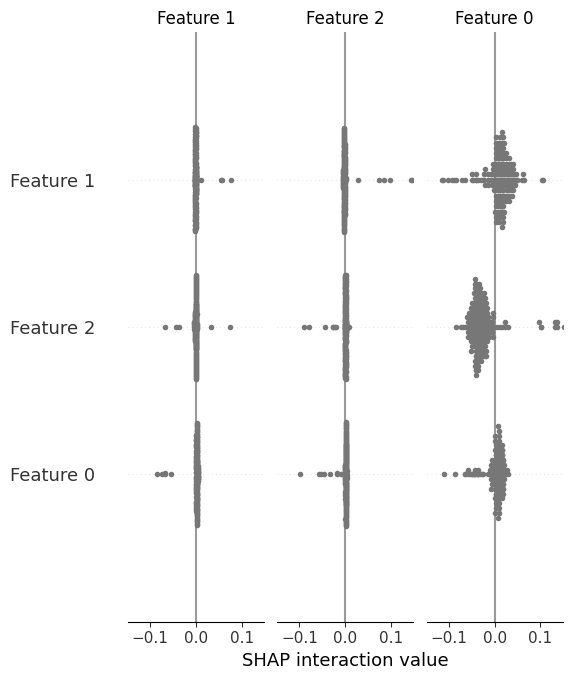

In [198]:
import shap
import joblib

from pathlib import Path
import joblib

MODEL_PATH = (
    Path("..")
    / "models"
    / "cisia_emploi_random_forest_multimodal_ethique_renforce_balanced.joblib"
)
#MODEL_PATH = (
#    Path("..")
#    / "models"
#    / "cisia_emploi_random_forest_multimodal_complet_balanced.joblib"
#)



print(MODEL_PATH.resolve())

pipeline = joblib.load(MODEL_PATH)



X, y = load_scenario_dataset(
    data_path=DATA_PATH,
    scenario_name="multimodal_ethique_renforce",
)

X_sample = X.sample(
    n=min(200, len(X)),
    random_state=42
)

import numpy as np
import shap

from scipy import sparse

preprocessor = pipeline.named_steps["preprocess"]
model = pipeline.named_steps["classifier"]

# Transformation avec exactement le prétraitement appris pendant le train
X_transformed = preprocessor.transform(X_sample)

print("Type avant conversion :", type(X_transformed))
print("Dtype avant conversion :", getattr(X_transformed, "dtype", None))
print("Dimensions :", X_transformed.shape)

# SHAP TreeExplainer attend une matrice numérique dense
if sparse.issparse(X_transformed):
    X_transformed_numeric = X_transformed.toarray()
elif hasattr(X_transformed, "to_numpy"):
    X_transformed_numeric = X_transformed.to_numpy()
else:
    X_transformed_numeric = np.asarray(X_transformed)

X_transformed_numeric = X_transformed_numeric.astype(
    np.float64,
    copy=False,
)

print("Type après conversion :", type(X_transformed_numeric))
print("Dtype après conversion :", X_transformed_numeric.dtype)
print("Dimensions après conversion :", X_transformed_numeric.shape)

# Vérification avant SHAP
if not np.isfinite(X_transformed_numeric).all():
    raise ValueError(
        "La matrice transformée contient des valeurs NaN ou infinies."
    )

explainer = shap.TreeExplainer(model)

shap_values = explainer.shap_values(
    X_transformed_numeric,
    check_additivity=False,
)

shap.summary_plot(
    shap_values,
    X_transformed,
    show=True,
)

In [199]:
if isinstance(shap_values, list):
    # Anciennes versions de SHAP :
    # une matrice par classe
    shap_values_class_2 = shap_values[2]

else:
    shap_array = np.asarray(shap_values)

    if shap_array.ndim == 3:
        # Versions récentes :
        # observations × variables × classes
        shap_values_class_2 = shap_array[:, :, 2]

    elif shap_array.ndim == 2:
        # Cas binaire ou sortie déjà limitée à une classe
        shap_values_class_2 = shap_array

    else:
        raise ValueError(
            f"Forme SHAP non reconnue : {shap_array.shape}"
        )

In [200]:
feature_names = (
    pipeline.named_steps["preprocess"]
    .get_feature_names_out()
)

print(len(feature_names))
print(feature_names[:10])


172
['num__anciennete_poste_ans' 'cat__code_rome_vise_A1202'
 'cat__code_rome_vise_A1203' 'cat__code_rome_vise_A1301'
 'cat__code_rome_vise_A1401' 'cat__code_rome_vise_A1501'
 'cat__code_rome_vise_C1102' 'cat__code_rome_vise_C1110'
 'cat__code_rome_vise_C1201' 'cat__code_rome_vise_C1302']


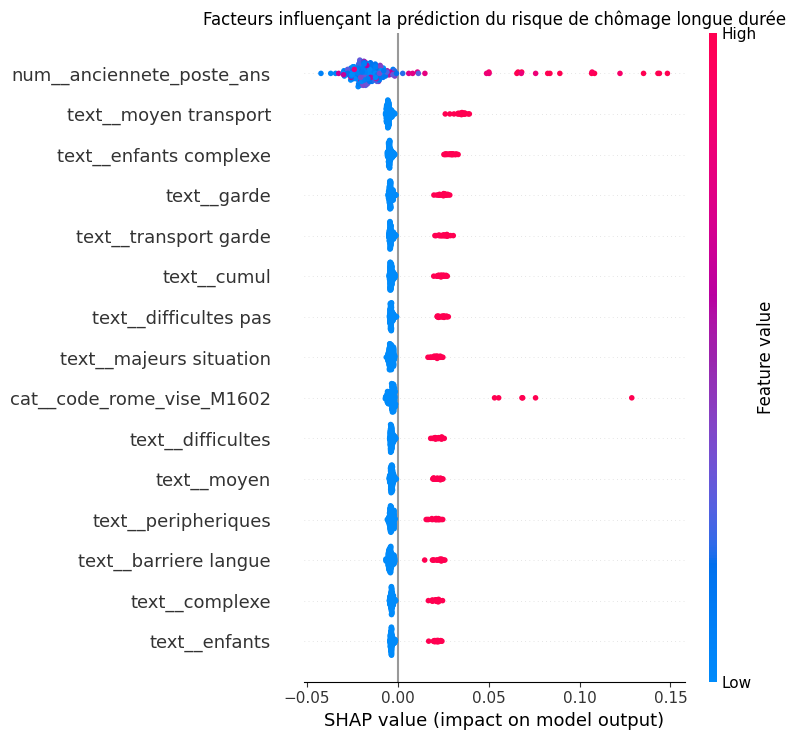

In [201]:
import matplotlib.pyplot as plt

shap.summary_plot(
    shap_values_class_2,
    X_transformed_numeric,
    feature_names=feature_names,
    max_display=15,
    show=False,
)

plt.title(
    "Facteurs influençant la prédiction du risque de chômage longue durée"
)

plt.tight_layout()
plt.show()

In [202]:
importance = np.abs(
    shap_values_class_2
).mean(axis=0)

top = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importance,
    })
    .sort_values(
        "importance",
        ascending=False,
    )
)

top.head(20)

,feature,importance
0,num__anciennete_poste_ans,0.024026
118,text__moyen transport,0.008254
85,text__enfants complexe,0.007070
96,text__garde,0.006153
164,text__transport garde,0.006054
77,text__cumul,0.005751
81,text__difficultes pas,0.005746
109,text__majeurs situation,0.005494
38,cat__code_rome_vise_M1602,0.005458
80,text__difficultes,0.005406


### 7.2 Analyse des erreurs et stratégies de fallback

🎯 Identifier où le modèle échoue, et **concevoir le filet de sécurité** : que se passe-t-il quand le modèle a tort, ou qu'il ne sait pas ?

💡 Trois leviers de conception à documenter explicitement (la **surveillance** de ces seuils se traite en §9.4, pas ici) :

| Levier | Question à trancher | Exemple concret |
|---|---|---|
| **Rejection threshold** | À quel niveau de confiance je préfère m'abstenir plutôt que prédire ? | *[ex: si proba ∈ [0.4, 0.6], on n'émet pas de prédiction]* |
| **Abstention contrôlée** | Que renvoie l'API quand le modèle s'abstient ? | *[ex: HTTP 422 + payload « confiance insuffisante » + flag HITL]* |
| **Escalade humaine (HITL)** | Qui prend la main, sous quel délai, avec quelle interface ? | *[ex: file Slack #fastia-hitl, SLA 4h ouvrées, audit a posteriori]* |

⚠️ Sans ces 3 éléments, ton modèle n'a pas de plan de fallback — il **n'est pas déployable en prod sur un usage à enjeu**. C'est un attendu C8 N3 (M6) et C7 N3 (M8). Le code ci-dessous analyse les erreurs résiduelles pour **informer** ces 3 choix (où placer le seuil, quels profils escalader).

In [ ]:
# 7.2 Analyse des erreurs et profils à escalader
# - Matrice de confusion détaillée par profil (variables sensibles incluses)
# - Distribution des probabilités prédites sur les erreurs : où placer le seuil de rejet ?
# - Caractérisation des profils faux positifs / faux négatifs : escalade humaine prioritaire ?

### 7.3 Message au client (langage métier)

*[2-3 paragraphes lisibles par un décideur non technique. Trois messages-clés à retenir.]*

### 7.4 📝 Synthèse interprétation

*[Variables-clés, profils mal prédits, vigilance opérationnelle.]*

---
## 8. Industrialisation

**Compétences** : C6 (implémenter le modèle), C7 (architecture cible)

🎯 Transformer le modèle en **service exploitable** : API, UI, conteneurs, tracking d'expériences.

> ⚠️ **Cette section ne contient PAS le code de l'API/UI.** Le code vit dans le **repo Git** associé.  
> Dans le notebook, on met uniquement :
> 1. **Description architecturale** (texte)
> 2. **1 schéma** d'architecture (Mermaid, draw.io export, ou image)
> 3. **Lien vers le repo Git** + dossiers concernés
> 4. **Captures d'écran clés** (UI, dashboard, OpenAPI Swagger, workflow CI/CD vert)
> 5. **Justifications des choix techniques** (pourquoi FastAPI plutôt que Flask, pourquoi MLflow plutôt que `experiments.md`, etc.)

⚠️ Attendus certif (présents dans le repo, **référencés** dans cette section du notebook) :  
- API FastAPI avec routes `/predict`, `/train`, `/health`  
- Validation Pydantic des entrées  
- Logging structuré (Loguru)  
- Tests pytest  
- Conteneurisation Docker  
- CI/CD GitHub Actions  
- Tracking MLflow

### 8.1 Persistance du modèle

*[Quel modèle est servi (`pipeline.joblib` versionné), quelle stratégie de persistance, quelle traçabilité (MLflow run id ou alternative `experiments.md`).]*

### 8.2 API de service

**Repo associé** : `<lien GitHub>` — dossier `api/`

| Route | Méthode | Rôle | Validation |
|---|---|---|---|
| `/health` | GET | santé du service | — |
| `/predict` | POST | prédiction unitaire | Pydantic |
| `/train` | POST | (option) déclenche un réentraînement | Pydantic + auth |

*[Inclure ici 1 capture Swagger ou un schéma de l'API.]*

### 8.3 Interface utilisateur

*[Streamlit / Gradio / autre. Capture dans `docs/`.]*

### 8.4 Schéma d'architecture

*[1 schéma simple : sources données → préprocessing → modèle → API → UI → monitoring.  
Tu peux utiliser un bloc Mermaid (rendu natif sur GitHub et Jupyter récents) :]*

```mermaid
graph LR
  D[(Données)] --> P[Préprocessing] --> M[Modèle .joblib]
  M --> A[FastAPI]
  A --> U[UI Streamlit]
  A --> L[(Logs)]
  L --> Mo[Monitoring]
```

### 8.5 Conteneurisation & CI/CD

*[Dockerfile, docker-compose.yml, workflow GitHub Actions (build → test → push). Captures d'écran d'un run CI vert. Liens vers les fichiers du repo.]*

### 8.6 📝 Synthèse industrialisation

*[Pile retenue, choix d'architecture, points encore ouverts.]*

---
## 9. Suivi en production & amélioration continue

**Compétences** : C8 (mesurer performance), C9 (amélioration continue)

🎯 Anticiper la dérive et la maintenance du modèle après mise en prod.

💡 Drift = data drift (entrées qui changent) vs concept drift (la cible change de comportement).  
⚠️ Pas de monitoring = pas de prod. Même un dashboard simple Streamlit suffit pour démarrer.

### 9.1 Métriques à surveiller

| Type | Métrique | Seuil d'alerte | Source |
|---|---|---|---|
| Modèle | F1 hebdo | < baseline - 0.05 | logs API |
| Données | PSI variables clés | > 0.2 | batch journalier |
| Système | latence p95 | > 500 ms | Prometheus |

### 9.2 Boucle de rétroaction

*[Comment les retours utilisateurs / annotations correctives reviennent dans les données d'entraînement ?]*

### 9.3 Plan de réentraînement

*[Trigger (calendaire ? performance ? volume nouvelles données ?), automatisation, validation avant mise en prod.]*

### 9.4 Robustesse en exploitation

🎯 Surveiller les **conditions de défaillance** une fois en prod, en complément des stratégies de fallback définies en §7.2 (côté conception).

💡 La conception du fallback (où placer le seuil, qui escalader) vit en §7.2. Ici on instrumente la **mesure** et le **déclenchement** :

| Axe | Métrique opérationnelle | Action automatique |
|---|---|---|
| **OOD (Out-Of-Distribution)** | Distance Mahalanobis ou score d'isolation sur les entrées | Logger les inputs hors-distribution, déclencher abstention ou escalade humaine (cf §7.2) |
| **Drift du seuil de rejet** | Taux d'abstention / part de prédictions sous seuil de confiance | Réviser le rejection threshold si dérive > 20 % sur 4 semaines glissantes |
| **Calibration** | Brier score, courbe de calibration mensuelle | Recalibrer (Platt, isotonic) sans réentraîner le modèle complet si seule la calibration dérive |

⚠️ La chaîne conception → exploitation doit rester explicite. §7.2 définit le filet de sécurité, §9.4 le surveille. Casser cette chaîne (fallback conçu mais jamais mesuré) = attendu C8 N3 non atteint.

### 9.5 📝 Synthèse amélioration continue

*[Cadence de surveillance, déclencheurs de réentraînement, plan de remédiation en cas de dérive.]*

---
## 📎 Annexes

### A. Glossaire métier & technique

### B. Sources & bibliographie

- *[Datasets, articles, documentation technique consultés]*

### C. Décisions techniques détaillées

*[Justifications longues qu'on ne met pas dans le corps du notebook pour le garder lisible.]*

### D. Journal de bord

**Pendant la formation**, le journal de bord est tenu **séparément** dans `journal-de-bord.ipynb` (plus pratique pour le rythme journalier).

⚠️ **Pour la certification**, les deux fichiers doivent être **fusionnés en un seul notebook** (cf. fiche descriptive Atlas IA — un cahier électronique unique).

#### Méthode 1 — Script de fusion (recommandée, ~30 secondes)

Un script est fourni à la racine du repo formation : `scripts/merge_for_certif.py`.

```bash
python scripts/merge_for_certif.py mon_notebook.ipynb journal-de-bord.ipynb rendu_certif.ipynb
```

Le script localise automatiquement le titre « D. Journal de bord » dans le notebook principal et y insère les cellules du journal dans l'ordre. Il produit un nouveau fichier sans modifier les sources.

#### Méthode 2 — Fusion manuelle dans JupyterLab (~5 min)

1. Ouvrir les **deux notebooks** côte à côte dans JupyterLab (drag-and-drop dans deux colonnes).
2. Dans le journal : cliquer sur la première cellule « Jour 1 », puis **Maj-clic** sur la dernière pour tout sélectionner sauf l'intro.
3. **Edit > Copy Cells** (`Ctrl/Cmd + Shift + C`).
4. Dans le notebook principal : cliquer sous le titre « D. Journal de bord ».
5. **Edit > Paste Cells Below** (`Ctrl/Cmd + Shift + V`).
6. Vérifier l'ordre chronologique.
7. **Kernel > Restart & Run All** : aucune cellule ne doit casser.
8. Sauvegarder sous un **nouveau nom** (ex : `<prenom>_certif_v1.ipynb`) — ne pas écraser les sources.

#### Vérification finale (les deux méthodes)

- [ ] Le notebook fusionné s'exécute de bout en bout sans erreur.
- [ ] Toutes les images du journal s'affichent (sinon : passer en chemins absolus ou inliner).
- [ ] Aucune référence à des fichiers externes hors du repo (ou alors les inclure dans le ZIP de rendu).
- [ ] Une seule version finale, datée, dans le ZIP envoyé au jury.

⚠️ **Tester la fusion 2-3 jours avant le rendu**, pas le jour J.

#### Export PDF (optionnel, pour la soutenance)

```bash
jupyter nbconvert --to pdf rendu_certif.ipynb
```